In [51]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import altair as alt

### Load Data:

In [2]:
atl06sr_gdf = pickle.load(open('../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked_fscapresence.pkl', 'rb'))

In [3]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

In [4]:
atl06sr_gdf = atl06sr_gdf.clip(sierras.to_crs(atl06sr_gdf.crs))

In [5]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [52]:
atl06sr_gdf_snowy = atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20)].copy()
atl06sr_gdf_snowy['n'] = atl06sr_gdf_snowy.groupby('acqdate')['acqdate'].transform('count')

In [54]:
atl06sr_gdf_snowy_100 = atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100].copy()

In [7]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [8]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [9]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs.rio.clip(sierras.geometry)
swe_sca_ds_sierras = swe_sca_ds.rio.clip(sierras.geometry)

In [ ]:
# swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs_sierras.rename({'y': 'lat', 'x': 'lon'})
# swe_sca_ds_sierras = swe_sca_ds_sierras.rename({'y': 'lat', 'x': 'lon'})

In [14]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_sierras.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) ))

In [15]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [16]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [17]:
# 4. Apply mask
swe_sca_ds_roi = swe_sca_ds_sierras.where(mask) #.compute()

In [18]:
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_sierras.where(mask)

### Get timeseries of median/average reanalysis snow depth for all years:

In [17]:
#swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_roi.rename({'y': 'lat', 'x': 'lon'})

In [ ]:
#swe_sca_ds_roi = swe_sca_ds_roi.rename({'y': 'lat', 'x': 'lon'})

In [15]:
# 5. Compute spatial median
#median_sd_allyrs = swe_sca_ds_allyrs_roi.SD_Post.median(dim=('lat', 'lon'), skipna=True).compute()
median_sd = swe_sca_ds_roi.SD_Post.median(dim=('lat', 'lon'), skipna=True).compute()

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [ ]:
# 5. Compute spatial median
median_swe_allyrs = swe_sca_ds_allyrs_roi.SWE_Post.median(dim=('lat', 'lon'), skipna=True).compute()

In [16]:
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_roi.rename({'lat': 'y', 'lon': 'x'})

In [17]:
swe_sca_ds_roi = swe_sca_ds_roi.rename({'lat': 'y', 'lon': 'x'})

### Sample Reanalysis at ICESat-2 points for March 17 2019:

In [21]:
# Define date of interest
date_of_interest = pd.Timestamp('2019-03-17')
current_year = 2019

# 1. Subset atl06sr_gdf to the date of interest
atl06sr_subset = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt'].dt.date == date_of_interest.date()) & (atl06sr_gdf_snowy['n']>100)].copy()

# Get lat/lon coordinates from the geometry
lons = atl06sr_subset.geometry.x.values
lats = atl06sr_subset.geometry.y.values

In [22]:
# 3. Sample reanalysis snow depth data on March 17 for each year (1985-2021, excluding 2019)
for year in range(1985, 2022):
    
    # Determine the water year (Oct-Sep, so March 2019 is WY 2019)
    water_year = year
    
    # Get the target date for this year (March 17)
    target_date = pd.Timestamp(f'{year}-03-17')
    
    # Select the snow depth data for this date
    sd_on_date = swe_sca_ds_allyrs_roi['SD_Post'].sel(time=target_date, method='nearest')
    
    # Sample at ICESat-2 points using linear interpolation
    sampled_sd = sd_on_date.interp(
        x=xr.DataArray(lons, dims='points'),
        y=xr.DataArray(lats, dims='points'),
        method='linear'
    ).values
    
    # Add to the dataframe
    atl06sr_subset[f'wy_{water_year}'] = sampled_sd

print(f"Subset dataframe shape: {atl06sr_subset.shape}")
print(f"Number of ICESat-2 points on {date_of_interest.date()}: {len(atl06sr_subset)}")
print(f"Columns added: {[col for col in atl06sr_subset.columns if 'eof' in col or 'wy_' in col]}")


Subset dataframe shape: (10706, 87)
Number of ICESat-2 points on 2019-03-17: 10706
Columns added: ['wy_1985', 'wy_1986', 'wy_1987', 'wy_1988', 'wy_1989', 'wy_1990', 'wy_1991', 'wy_1992', 'wy_1993', 'wy_1994', 'wy_1995', 'wy_1996', 'wy_1997', 'wy_1998', 'wy_1999', 'wy_2000', 'wy_2001', 'wy_2002', 'wy_2003', 'wy_2004', 'wy_2005', 'wy_2006', 'wy_2007', 'wy_2008', 'wy_2009', 'wy_2010', 'wy_2011', 'wy_2012', 'wy_2013', 'wy_2014', 'wy_2015', 'wy_2016', 'wy_2017', 'wy_2018', 'wy_2019', 'wy_2020', 'wy_2021']


### Restrict the area that I compute the SA for using the reanalysis data (that was masked earlier):

In [23]:
atl06sr_subset = atl06sr_subset.dropna(subset=['wy_2019']).copy()

Text(0.5, 0.98, 'ICESat-2 SD (left) and Reanalysis SD (right) on March 17, 2019')

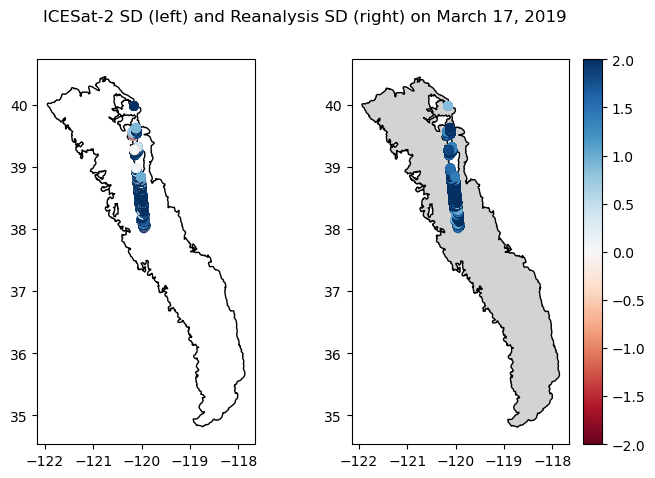

In [24]:
fig, ax = plt.subplots(1,2, figsize=(8,5))
sierras.plot(ax=ax[0], facecolor='none', edgecolor='k')
atl06sr_subset.plot(ax=ax[0], column='icesat2_3dep_dif',vmin=-2, vmax=2, cmap='RdBu')

sierras.plot(ax=ax[1], facecolor='lightgrey', edgecolor='k')
atl06sr_subset.plot(ax=ax[1], column='wy_2019', vmin=-2, vmax=2, cmap='RdBu', legend=True)

plt.suptitle('ICESat-2 SD (left) and Reanalysis SD (right) on March 17, 2019')

In [25]:
# Extract columns with 'wy_' prefix and compute median for each year
wy_cols = [col for col in atl06sr_subset.columns if col.startswith('wy_')]
median_values = {col.replace('wy_', ''): atl06sr_subset[col].median() for col in wy_cols}

# Create dataframe with water years as index
median_by_year_df = pd.DataFrame.from_dict(median_values, orient='index', columns=['median_sd'])
median_by_year_df.index.name = 'water_year'
median_by_year_df.index = median_by_year_df.index.astype(int)
median_by_year_df = median_by_year_df.sort_index()

# Compute mean and std excluding 2019
median_sd_no2019 = median_by_year_df.loc[median_by_year_df.index != 2019, 'median_sd']
historical_mean = median_sd_no2019.mean()
historical_std = median_sd_no2019.std()

print(f"Historical mean (excl. 2019): {historical_mean:.4f} m")
print(f"Historical std (excl. 2019): {historical_std:.4f} m")
median_by_year_df

Historical mean (excl. 2019): 1.2972 m
Historical std (excl. 2019): 0.6249 m


,median_sd
water_year,
1985,0.762332
1986,2.299411
1987,0.802537
1988,0.541187
1989,1.103145
1990,1.166970
1991,1.232781
1992,1.144627
1993,2.725763


In [26]:
march172019_sd = atl06sr_subset['icesat2_3dep_dif'].median()
march172019_sa = (march172019_sd - historical_mean) / historical_std

In [27]:
median_by_year_df.loc[(median_by_year_df.index == 2019), 'median_sd'].values[0]

np.float64(2.4809304891615174)

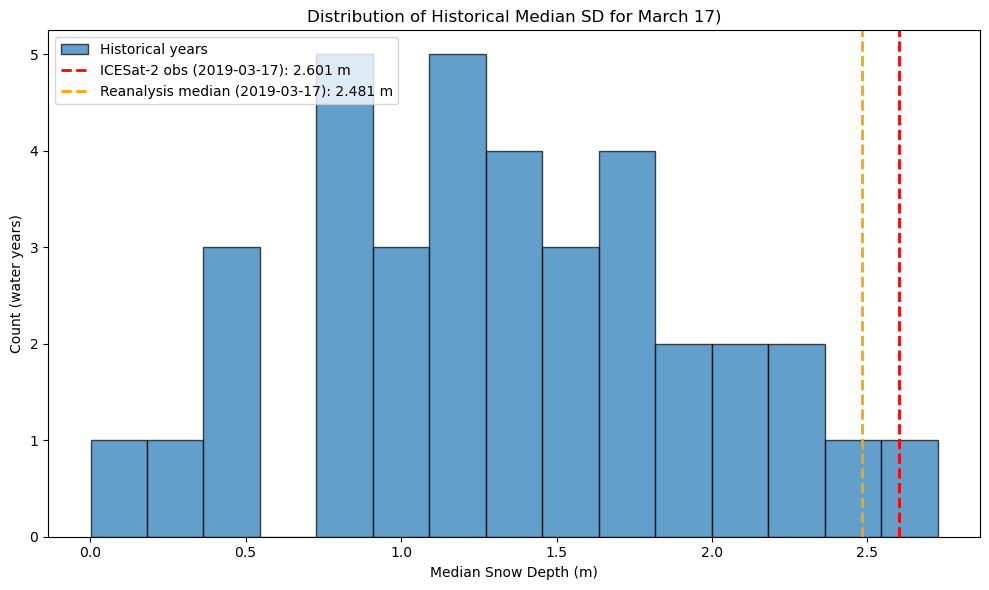


ICESat-2 observed median SD: 2.086 m
Historical mean: 1.329 m
Historical std: 0.646 m
Standardized anomaly: 2.60


In [28]:
# Plot histogram of historical median SD values with ICESat-2 observed value
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of historical median SD values
ax.hist(median_by_year_df['median_sd'].dropna(), bins=15, edgecolor='black', alpha=0.7, label='Historical years')

# Get the ICESat-2 observed value for 2019-03-17
#is2_value = medians_both.loc[medians_both['date'] == '2019-03-17', 'icesat2_3dep_dif'].values[0]

# Add vertical dashed line for ICESat-2 observation
ax.axvline(march172019_sd, color='red', linestyle='--', linewidth=2, label=f'ICESat-2 obs (2019-03-17): {march172019_sd:.3f} m')

ax.axvline(median_by_year_df.loc[median_by_year_df.index == 2019, 'median_sd'].values[0], color='orange', linestyle='--', linewidth=2, label=f'Reanalysis median (2019-03-17): {median_by_year_df.loc[median_by_year_df.index == 2019, 'median_sd'].values[0]:.3f} m')

# Add labels and legend
ax.set_xlabel('Median Snow Depth (m)')
ax.set_ylabel('Count (water years)')
ax.set_title(f'Distribution of Historical Median SD for March 17)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nICESat-2 observed median SD: {march172019_sa:.3f} m")
print(f"Historical mean: {median_by_year_df['median_sd'].mean():.3f} m")
print(f"Historical std: {median_by_year_df['median_sd'].std():.3f} m")
print(f"Standardized anomaly: {march172019_sd:.2f}")

In [29]:
# Select only the date of interest in the snow depth data

# 1. Select March 17 of each year
sd_allyrs_march17 = swe_sca_ds_allyrs_roi.SD_Post.sel(time=( (swe_sca_ds_allyrs_roi['time'].dt.month == 3) & (swe_sca_ds_allyrs_roi['time'].dt.day == 17) ))

# 2. Exclude 2019 from the calculations (that's the observation year)
sd_allyrs_march17_no2019 = sd_allyrs_march17.sel(time=sd_allyrs_march17['time'].dt.year != 2019)

# 3. Compute mean March 17 snow depth across years (excluding 2019)
sd_allyrs_march17_mean = sd_allyrs_march17_no2019.mean(dim='time', skipna=True).compute()



Years included in mean/std calculation: [1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2020 2021]


In [ ]:
# 4. Compute standard deviation March 17 across years (excluding 2019)
sd_allyrs_march17_std = sd_allyrs_march17_no2019.std(dim='time', skipna=True).compute()

print(f"Years included in mean/std calculation: {sd_allyrs_march17_no2019['time'].dt.year.values}")

In [30]:
# Convert standardized anomaly back to snow depth: x = SA * std + mean

sa_sd_test_track = (march172019_sa * sd_allyrs_march17_std) + sd_allyrs_march17_mean

In [28]:
sd_allyrs_march17

<xarray.DataArray 'SD_Post' (time: 37, y: 1267, x: 919)> Size: 172MB
dask.array<getitem, shape=(37, 1267, 919), dtype=float32, chunksize=(37, 263, 188), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * x            (x) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
  * time         (time) datetime64[ns] 296B 1985-03-17 1986-03-17 ... 2021-03-17
    spatial_ref  int64 8B 0
Attributes:
    Units:    meters

In [31]:
sa_sd_test_track_dif = (sa_sd_test_track - swe_sca_ds_roi.SD_Post.sel(time='2019-03-17')).compute()

Text(0.5, 1.0, 'Difference (SA Estimate - Reanalysis)')

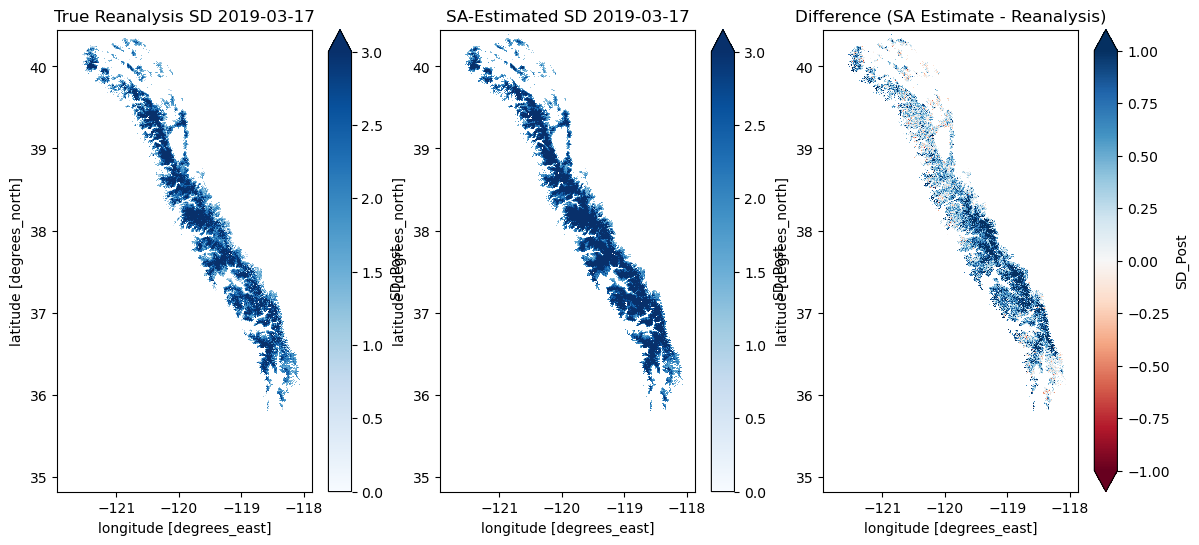

In [32]:
fig, ax = plt.subplots(1,3,figsize=(14, 6))

swe_sca_ds_roi.SD_Post.sel(time='2019-03-17').plot(ax=ax[0], cmap='Blues', vmin=0, vmax=3)
ax[0].set_title('True Reanalysis SD 2019-03-17')

sa_sd_test_track.plot(ax=ax[1], cmap='Blues', vmin=0, vmax=3)
ax[1].set_title('SA-Estimated SD 2019-03-17')

sa_sd_test_track_dif.plot(ax=ax[2], cmap='RdBu', vmin=-1, vmax=1)
ax[2].set_title('Difference (SA Estimate - Reanalysis)')


In [33]:
# Calculate metrics
true_sd = swe_sca_ds_roi.SD_Post.sel(time='2019-03-17').values.flatten()
pred_sd = sa_sd_test_track.values.flatten()

# Remove NaN values
valid_mask = ~np.isnan(true_sd) & ~np.isnan(pred_sd)
true_sd_valid = true_sd[valid_mask]
pred_sd_valid = pred_sd[valid_mask]

# Bias (mean error)
bias = np.mean(pred_sd_valid - true_sd_valid)

# RMSE
rmse = np.sqrt(np.mean((pred_sd_valid - true_sd_valid)**2))

# R-squared
ss_res = np.sum((true_sd_valid - pred_sd_valid)**2)
ss_tot = np.sum((true_sd_valid - np.mean(true_sd_valid))**2)
r_squared = 1 - (ss_res / ss_tot)

# Percent Bias (PBIAS)
pbias = 100 * np.sum(pred_sd_valid - true_sd_valid) / np.sum(true_sd_valid)

print(f"Metrics for SA-Estimated vs True Reanalysis SD (2019-03-17):")
print(f"  Bias:      {bias:.4f} m")
print(f"  RMSE:      {rmse:.4f} m")
print(f"  R²:        {r_squared:.4f}")
print(f"  PBIAS:     {pbias:.2f}%")
print(f"  N points:  {len(true_sd_valid)}")

Metrics for SA-Estimated vs True Reanalysis SD (2019-03-17):
  Bias:      0.5078 m
  RMSE:      0.7099 m
  R²:        0.3959
  PBIAS:     21.91%
  N points:  110501


## Repeat for a southern track on 2019-04-06:

In [34]:
# Define date of interest
date_of_interest = pd.Timestamp('2019-04-06')
current_year = 2019

# 1. Subset atl06sr_gdf to the date of interest
atl06sr_subset_south = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt'].dt.date == date_of_interest.date()) & (atl06sr_gdf_snowy['n']>100)].copy()

# Get lat/lon coordinates from the geometry
lons = atl06sr_subset_south.geometry.x.values
lats = atl06sr_subset_south.geometry.y.values

In [36]:
# 3. Sample reanalysis snow depth data on April 6 for each year (1985-2021, excluding 2019)
for year in range(1985, 2022):
    # if year == current_year:
    #     continue  # Skip the current year (2019)
    
    # Determine the water year (Oct-Sep, so April 2019 is WY 2019)
    water_year = year
    
    # Get the target date for this year (April 6)
    target_date = pd.Timestamp(f'{year}-04-06')
    
    # Select the snow depth data for this date
    sd_on_date = swe_sca_ds_allyrs_roi['SD_Post'].sel(time=target_date, method='nearest')
    
    # Sample at ICESat-2 points using linear interpolation
    sampled_sd = sd_on_date.interp(
        x=xr.DataArray(lons, dims='points'),
        y=xr.DataArray(lats, dims='points'),
        method='linear'
    ).values
    
    # Add to the dataframe
    atl06sr_subset_south[f'wy_{water_year}'] = sampled_sd

print(f"Subset dataframe shape: {atl06sr_subset_south.shape}")
print(f"Number of ICESat-2 points on {date_of_interest.date()}: {len(atl06sr_subset_south)}")
print(f"Columns added: {[col for col in atl06sr_subset_south.columns if 'eof' in col or 'wy_' in col]}")


Subset dataframe shape: (8776, 87)
Number of ICESat-2 points on 2019-04-06: 8776
Columns added: ['wy_1985', 'wy_1986', 'wy_1987', 'wy_1988', 'wy_1989', 'wy_1990', 'wy_1991', 'wy_1992', 'wy_1993', 'wy_1994', 'wy_1995', 'wy_1996', 'wy_1997', 'wy_1998', 'wy_1999', 'wy_2000', 'wy_2001', 'wy_2002', 'wy_2003', 'wy_2004', 'wy_2005', 'wy_2006', 'wy_2007', 'wy_2008', 'wy_2009', 'wy_2010', 'wy_2011', 'wy_2012', 'wy_2013', 'wy_2014', 'wy_2015', 'wy_2016', 'wy_2017', 'wy_2018', 'wy_2019', 'wy_2020', 'wy_2021']


### Restrict the area that I compute the SA for using the reanalysis data (that was masked earlier):

In [39]:
atl06sr_subset_south = atl06sr_subset_south.dropna(subset=['wy_2019']).copy()

Text(0.5, 0.98, 'ICESat-2 SD (left) and Reanalysis SD (right) on April 6, 2019')

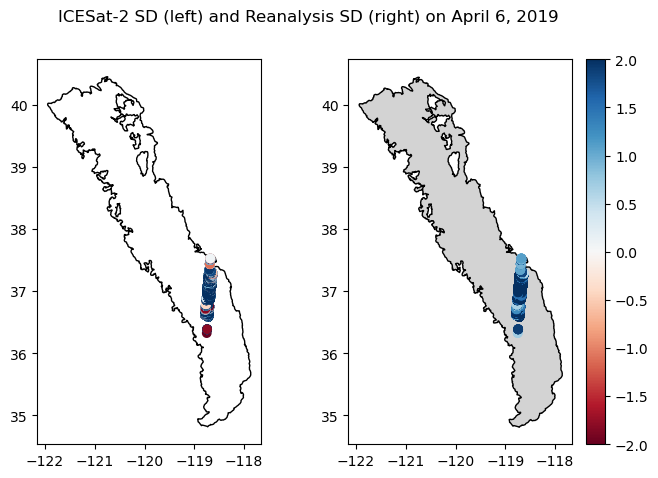

In [38]:
fig, ax = plt.subplots(1,2, figsize=(8,5))
sierras.plot(ax=ax[0], facecolor='none', edgecolor='k')
atl06sr_subset_south.plot(ax=ax[0], column='icesat2_3dep_dif',vmin=-2, vmax=2, cmap='RdBu')

sierras.plot(ax=ax[1], facecolor='lightgrey', edgecolor='k')
atl06sr_subset_south.plot(ax=ax[1], column='wy_2019', vmin=-2, vmax=2, cmap='RdBu', legend=True)

plt.suptitle('ICESat-2 SD (left) and Reanalysis SD (right) on April 6, 2019')

In [40]:
# Extract columns with 'wy_' prefix and compute median for each year
wy_cols = [col for col in atl06sr_subset.columns if col.startswith('wy_')]
median_values = {col.replace('wy_', ''): atl06sr_subset[col].median() for col in wy_cols}

# Create dataframe with water years as index
median_by_year_df = pd.DataFrame.from_dict(median_values, orient='index', columns=['median_sd'])
median_by_year_df.index.name = 'water_year'
median_by_year_df.index = median_by_year_df.index.astype(int)
median_by_year_df = median_by_year_df.sort_index()
median_by_year_df

# Compute mean and std excluding 2019
median_sd_no2019 = median_by_year_df.loc[median_by_year_df.index != 2019, 'median_sd']
historical_mean = median_sd_no2019.mean()
historical_std = median_sd_no2019.std()

print(f"Historical mean (excl. 2019): {historical_mean:.4f} m")
print(f"Historical std (excl. 2019): {historical_std:.4f} m")
median_by_year_df

Historical mean (excl. 2019): 1.2972 m
Historical std (excl. 2019): 0.6249 m


,median_sd
water_year,
1985,0.762332
1986,2.299411
1987,0.802537
1988,0.541187
1989,1.103145
1990,1.166970
1991,1.232781
1992,1.144627
1993,2.725763


In [41]:
april62019_sd = atl06sr_subset_south['icesat2_3dep_dif'].median()
april62019_sa = (april62019_sd - historical_mean) / historical_std

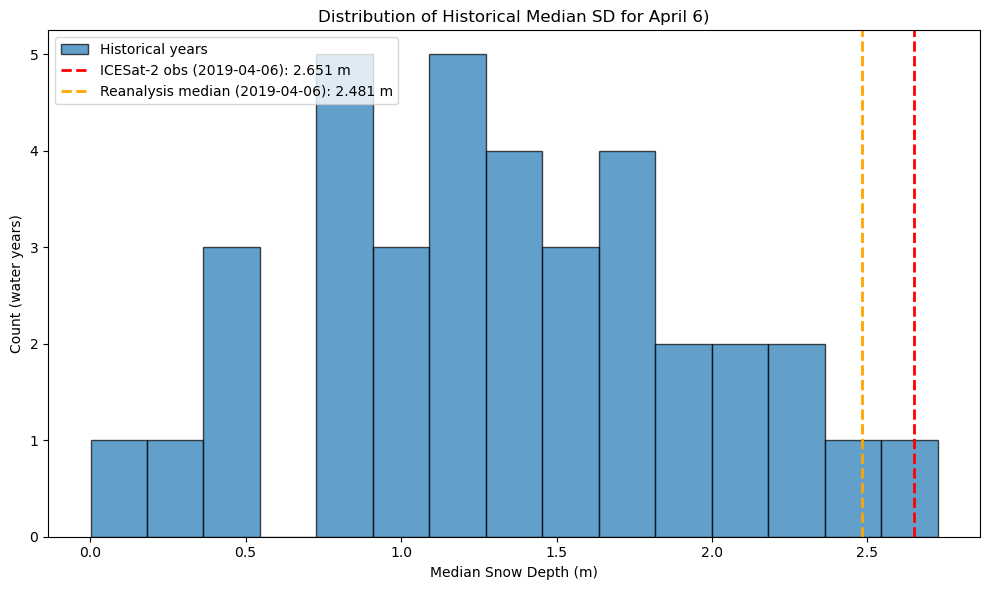


ICESat-2 observed median SD: 2.651 m
Historical mean: 1.297 m
Historical std: 0.625 m
Standardized anomaly: 2.17


In [42]:
# Plot histogram of historical median SD values with ICESat-2 observed value
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of historical median SD values
ax.hist(median_by_year_df['median_sd'].dropna(), bins=15, edgecolor='black', alpha=0.7, label='Historical years')

# Get the ICESat-2 observed value for 2019-03-17
#is2_value = medians_both.loc[medians_both['date'] == '2019-03-17', 'icesat2_3dep_dif'].values[0]

# Add vertical dashed line for ICESat-2 observation
ax.axvline(april62019_sd, color='red', linestyle='--', linewidth=2, label=f'ICESat-2 obs (2019-04-06): {april62019_sd:.3f} m')
ax.axvline(median_by_year_df.loc[median_by_year_df.index == 2019, 'median_sd'].values[0], color='orange', linestyle='--', linewidth=2, label=f'Reanalysis median (2019-04-06): {median_by_year_df.loc[median_by_year_df.index == 2019, 'median_sd'].values[0]:.3f} m')

# Add labels and legend
ax.set_xlabel('Median Snow Depth (m)')
ax.set_ylabel('Count (water years)')
ax.set_title(f'Distribution of Historical Median SD for April 6)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nICESat-2 observed median SD: {april62019_sd:.3f} m")
print(f"Historical mean: {historical_mean:.3f} m")
print(f"Historical std: {historical_std:.3f} m")
print(f"Standardized anomaly: {april62019_sa:.2f}")

In [43]:
# Select only the date of interest in the snow depth data

# 1. Select April 6 of each year
sd_allyrs_april6 = swe_sca_ds_allyrs_roi.SD_Post.sel(time=( (swe_sca_ds_allyrs_roi['time'].dt.month == 4) & (swe_sca_ds_allyrs_roi['time'].dt.day == 6) ))

# 2. Exclude 2019 from the calculations (that's the observation year)
sd_allyrs_april6_no2019 = sd_allyrs_april6.sel(time=sd_allyrs_april6['time'].dt.year != 2019)

# 3. Compute mean April 6 snow depth across years (excluding 2019)
sd_allyrs_april6_mean = sd_allyrs_april6_no2019.mean(dim='time', skipna=True).compute()

Years included in mean/std calculation: [1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2020 2021]


In [ ]:
# 4. Compute standard deviation April 6 across years (excluding 2019)
sd_allyrs_april6_std = sd_allyrs_april6_no2019.std(dim='time', skipna=True).compute()

print(f"Years included in mean/std calculation: {sd_allyrs_april6_no2019['time'].dt.year.values}")

In [44]:
# Convert standardized anomaly back to snow depth: x = SA * std + mean

sa_sd_test_track = (april62019_sa * sd_allyrs_april6_std) + sd_allyrs_april6_mean

In [45]:
sa_sd_test_track_dif = (sa_sd_test_track - swe_sca_ds_roi.SD_Post.sel(time='2019-04-06')).compute()

Text(0.5, 1.0, 'Difference (SA Estimate - Reanalysis)')

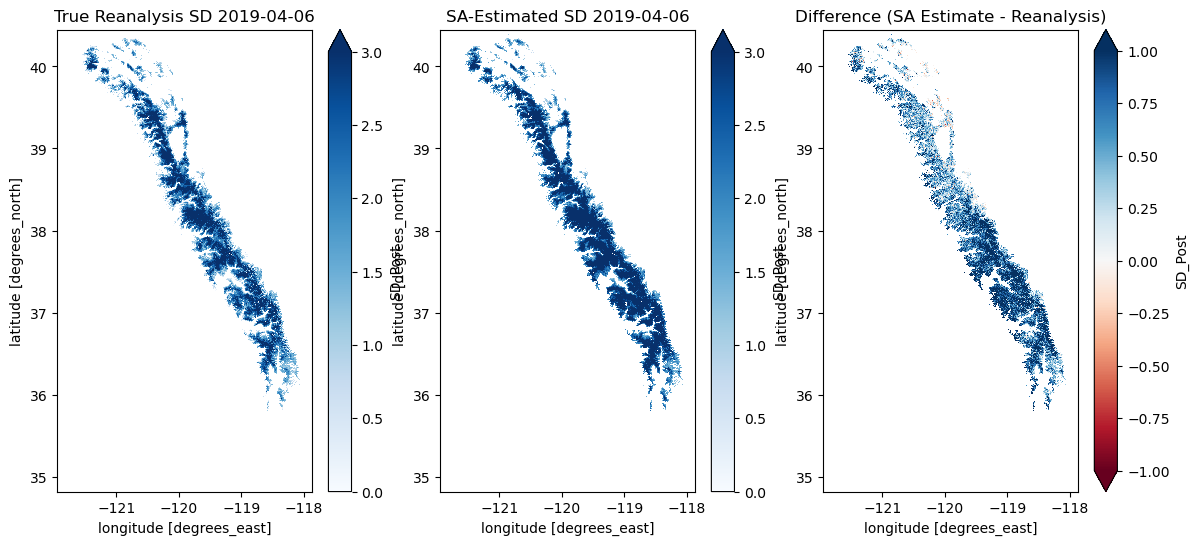

In [46]:
fig, ax = plt.subplots(1,3,figsize=(14, 6))

swe_sca_ds_roi.SD_Post.sel(time='2019-04-06').plot(ax=ax[0], cmap='Blues', vmin=0, vmax=3)
ax[0].set_title('True Reanalysis SD 2019-04-06')

sa_sd_test_track.plot(ax=ax[1], cmap='Blues', vmin=0, vmax=3)
ax[1].set_title('SA-Estimated SD 2019-04-06')

sa_sd_test_track_dif.plot(ax=ax[2], cmap='RdBu', vmin=-1, vmax=1)
ax[2].set_title('Difference (SA Estimate - Reanalysis)')


In [47]:
# Calculate metrics
true_sd = swe_sca_ds_roi.SD_Post.sel(time='2019-04-06').values.flatten()
pred_sd = sa_sd_test_track.values.flatten()

# Remove NaN values
valid_mask = ~np.isnan(true_sd) & ~np.isnan(pred_sd)
true_sd_valid = true_sd[valid_mask]
pred_sd_valid = pred_sd[valid_mask]

# Bias (mean error)
bias = np.mean(pred_sd_valid - true_sd_valid)

# RMSE
rmse = np.sqrt(np.mean((pred_sd_valid - true_sd_valid)**2))

# R-squared
ss_res = np.sum((true_sd_valid - pred_sd_valid)**2)
ss_tot = np.sum((true_sd_valid - np.mean(true_sd_valid))**2)
r_squared = 1 - (ss_res / ss_tot)

# Percent Bias (PBIAS)
pbias = 100 * np.sum(pred_sd_valid - true_sd_valid) / np.sum(true_sd_valid)

print(f"Metrics for SA-Estimated vs True Reanalysis SD (2019-04-06):")
print(f"  Bias:      {bias:.4f} m")
print(f"  RMSE:      {rmse:.4f} m")
print(f"  R²:        {r_squared:.4f}")
print(f"  PBIAS:     {pbias:.2f}%")
print(f"  N points:  {len(true_sd_valid)}")

Metrics for SA-Estimated vs True Reanalysis SD (2019-04-06):
  Bias:      0.6964 m
  RMSE:      0.8668 m
  R²:        0.3024
  PBIAS:     32.41%
  N points:  110501


## Assume the IS2 track median represents the true snow depth everywhere:

In [72]:
# Create a DataArray with same shape as swe_sca_ds_roi, filled with median IS2 value where valid
is2_median_march172019_da = swe_sca_ds_roi.SD_Post.sel(time='2019-03-17').copy()
is2_median_march172019_da = xr.where(~np.isnan(is2_median_march172019_da), march172019_sd, np.nan)
is2_median_march172019_da

<xarray.DataArray 'SD_Post' (y: 1267, x: 919)> Size: 9MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1267, 919))
Coordinates:
  * y            (y) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * x            (x) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
    time         datetime64[ns] 8B 2019-03-17
    spatial_ref  int64 8B 0

In [75]:
is2_median_march172019_da_dif = is2_median_march172019_da - swe_sca_ds_roi.SD_Post.sel(time='2019-03-17')

Text(0.5, 1.0, 'Difference (Median Estimate - Reanalysis)')

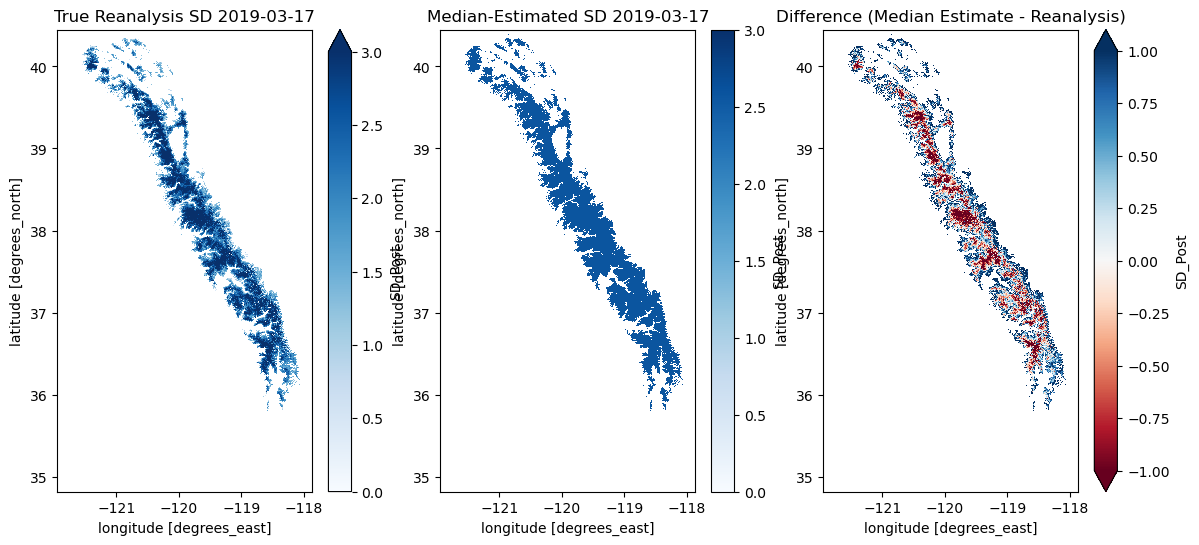

In [76]:
fig, ax = plt.subplots(1,3,figsize=(14, 6))

swe_sca_ds_roi.SD_Post.sel(time='2019-03-17').plot(ax=ax[0], cmap='Blues', vmin=0, vmax=3)
ax[0].set_title('True Reanalysis SD 2019-03-17')

is2_median_march172019_da.plot(ax=ax[1], cmap='Blues', vmin=0, vmax=3)
ax[1].set_title('Median-Estimated SD 2019-03-17')

is2_median_march172019_da_dif.plot(ax=ax[2], cmap='RdBu', vmin=-1, vmax=1)
ax[2].set_title('Difference (Median Estimate - Reanalysis)')


In [77]:
# Calculate metrics
true_sd = swe_sca_ds_roi.SD_Post.sel(time='2019-03-17').values.flatten()
pred_sd = is2_median_march172019_da.values.flatten()

# Remove NaN values
valid_mask = ~np.isnan(true_sd) & ~np.isnan(pred_sd)
true_sd_valid = true_sd[valid_mask]
pred_sd_valid = pred_sd[valid_mask]

# Bias (mean error)
bias = np.mean(pred_sd_valid - true_sd_valid)

# RMSE
rmse = np.sqrt(np.mean((pred_sd_valid - true_sd_valid)**2))

# R-squared
ss_res = np.sum((true_sd_valid - pred_sd_valid)**2)
ss_tot = np.sum((true_sd_valid - np.mean(true_sd_valid))**2)
r_squared = 1 - (ss_res / ss_tot)

# Percent Bias (PBIAS)
pbias = 100 * np.sum(pred_sd_valid - true_sd_valid) / np.sum(true_sd_valid)

print(f"Metrics for SA-Estimated vs True Reanalysis SD (2019-03-17):")
print(f"  Bias:      {bias:.4f} m")
print(f"  RMSE:      {rmse:.4f} m")
print(f"  R²:        {r_squared:.4f}")
print(f"  PBIAS:     {pbias:.2f}%")
print(f"  N points:  {len(true_sd_valid)}")

Metrics for SA-Estimated vs True Reanalysis SD (2019-03-17):
  Bias:      0.2560 m
  RMSE:      0.9485 m
  R²:        -0.0786
  PBIAS:     11.04%
  N points:  110501


In [78]:
# Create a DataArray with same shape as swe_sca_ds_roi, filled with median IS2 value where valid
is2_median_april62019_da = swe_sca_ds_roi.SD_Post.sel(time='2019-04-06').copy()
is2_median_april62019_da = xr.where(~np.isnan(is2_median_april62019_da), april62019_sd, np.nan)
is2_median_april62019_da

<xarray.DataArray 'SD_Post' (y: 1267, x: 919)> Size: 9MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(1267, 919))
Coordinates:
  * y            (y) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * x            (x) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
    time         datetime64[ns] 8B 2019-04-06
    spatial_ref  int64 8B 0

In [80]:
is2_median_april62019_da_dif = is2_median_april62019_da - swe_sca_ds_roi.SD_Post.sel(time='2019-04-06')

Text(0.5, 1.0, 'Difference (Median Estimate - Reanalysis)')

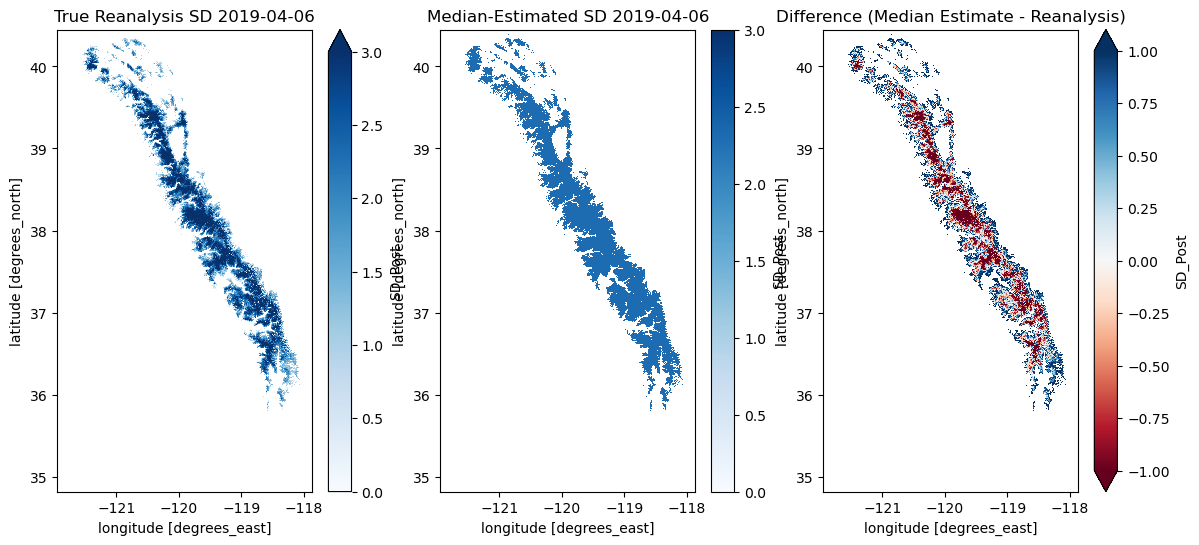

In [81]:
fig, ax = plt.subplots(1,3,figsize=(14, 6))

swe_sca_ds_roi.SD_Post.sel(time='2019-04-06').plot(ax=ax[0], cmap='Blues', vmin=0, vmax=3)
ax[0].set_title('True Reanalysis SD 2019-04-06')

is2_median_april62019_da.plot(ax=ax[1], cmap='Blues', vmin=0, vmax=3)
ax[1].set_title('Median-Estimated SD 2019-04-06')

is2_median_april62019_da_dif.plot(ax=ax[2], cmap='RdBu', vmin=-1, vmax=1)
ax[2].set_title('Difference (Median Estimate - Reanalysis)')


In [82]:
# Calculate metrics
true_sd = swe_sca_ds_roi.SD_Post.sel(time='2019-04-06').values.flatten()
pred_sd = is2_median_april62019_da.values.flatten()

# Remove NaN values
valid_mask = ~np.isnan(true_sd) & ~np.isnan(pred_sd)
true_sd_valid = true_sd[valid_mask]
pred_sd_valid = pred_sd[valid_mask]

# Bias (mean error)
bias = np.mean(pred_sd_valid - true_sd_valid)

# RMSE
rmse = np.sqrt(np.mean((pred_sd_valid - true_sd_valid)**2))

# R-squared
ss_res = np.sum((true_sd_valid - pred_sd_valid)**2)
ss_tot = np.sum((true_sd_valid - np.mean(true_sd_valid))**2)
r_squared = 1 - (ss_res / ss_tot)

# Percent Bias (PBIAS)
pbias = 100 * np.sum(pred_sd_valid - true_sd_valid) / np.sum(true_sd_valid)

print(f"Metrics for SA-Estimated vs True Reanalysis SD (2019-04-06):")
print(f"  Bias:      {bias:.4f} m")
print(f"  RMSE:      {rmse:.4f} m")
print(f"  R²:        {r_squared:.4f}")
print(f"  PBIAS:     {pbias:.2f}%")
print(f"  N points:  {len(true_sd_valid)}")

Metrics for SA-Estimated vs True Reanalysis SD (2019-04-06):
  Bias:      0.1491 m
  RMSE:      1.0485 m
  R²:        -0.0206
  PBIAS:     6.94%
  N points:  110501


# Now test for those two dates using smoothed ICESat-2 and historical stats:

In [83]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask', 'snow_presence', 'snow_presence_fsca',
       'acqdate_dt'],
      dtype='object')

In [ ]:
#atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [18]:
atl06sr_gdf_snowy = atl06sr_gdf[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20)].copy()
atl06sr_gdf_snowy['n'] = atl06sr_gdf_snowy.groupby('acqdate')['acqdate'].transform('count')

### Smooth the ICESat-2 and sampled Reanalysis medians:

In [19]:
medians_both = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['n']>100), ['icesat2_3dep_dif', 'reanalysis_sd','acqdate']].dropna().groupby('acqdate').median()

In [20]:
medians_both['date'] = pd.to_datetime(medians_both.index)

In [21]:
# Calculate 1-week (7-day) running median of icesat2_3dep_dif
# Using a trailing window that includes the current date
medians_both['running_median_1week'] = medians_both['icesat2_3dep_dif'].rolling(
    window=7, 
    min_periods=1  # Allow calculation even with fewer than 14 days at the start
).median()

# Calculate the median date of the rolling window    

# Convert dates to numeric, compute rolling median, convert back     

medians_both['running_median_1week_date'] = pd.to_datetime(medians_both['date'].astype(np.int64).rolling(window=7,min_periods=1).median())

# Calculate 1-week (7-day) running median of reanalysis_sd
# Using a trailing window that includes the current date
medians_both['reanalysis_running_median_1week'] = medians_both['reanalysis_sd'].rolling(
    window=7, 
    min_periods=1,  # Allow calculation even with fewer than 14 days at the start
    center=True
).median()
# Note: the sampled reanalysis uses the same rolling window dates as running_median_1week_date

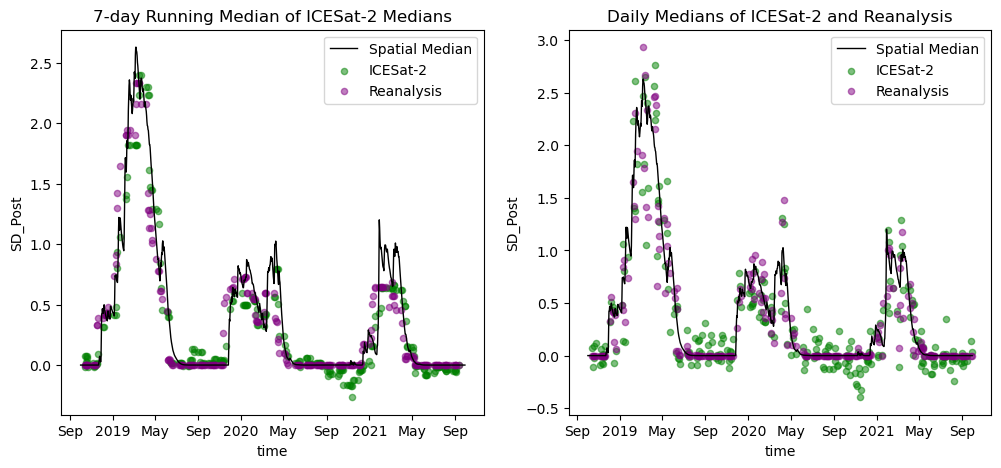

In [22]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

median_sd.plot(ax=ax[0], label='Spatial Median', color='k', linewidth=1)
ax[0].scatter(medians_both['running_median_1week_date'], medians_both['running_median_1week'], s=20, alpha=0.5, c='green', label='ICESat-2')
ax[0].scatter(medians_both['running_median_1week_date'], medians_both['reanalysis_running_median_1week'], s=20, alpha=0.5, c='purple', label='Reanalysis')
ax[0].set_title('7-day Running Median of ICESat-2 Medians')
ax[0].legend()

median_sd.plot(ax=ax[1], label='Spatial Median', color='k', linewidth=1)
ax[1].scatter(medians_both['date'], medians_both['icesat2_3dep_dif'], s=20, alpha=0.5, c='green', label='ICESat-2')
ax[1].scatter(medians_both['date'], medians_both['reanalysis_sd'], s=20, alpha=0.5, c='purple', label='Reanalysis')
ax[1].set_title('Daily Medians of ICESat-2 and Reanalysis')
ax[1].legend()

### Check the dates around april 1:

Number of points: 36319
Number of unique dates: 7
Date range: 2019-03-21 00:00:00 to 2019-04-15 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_8804/1359770804.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))


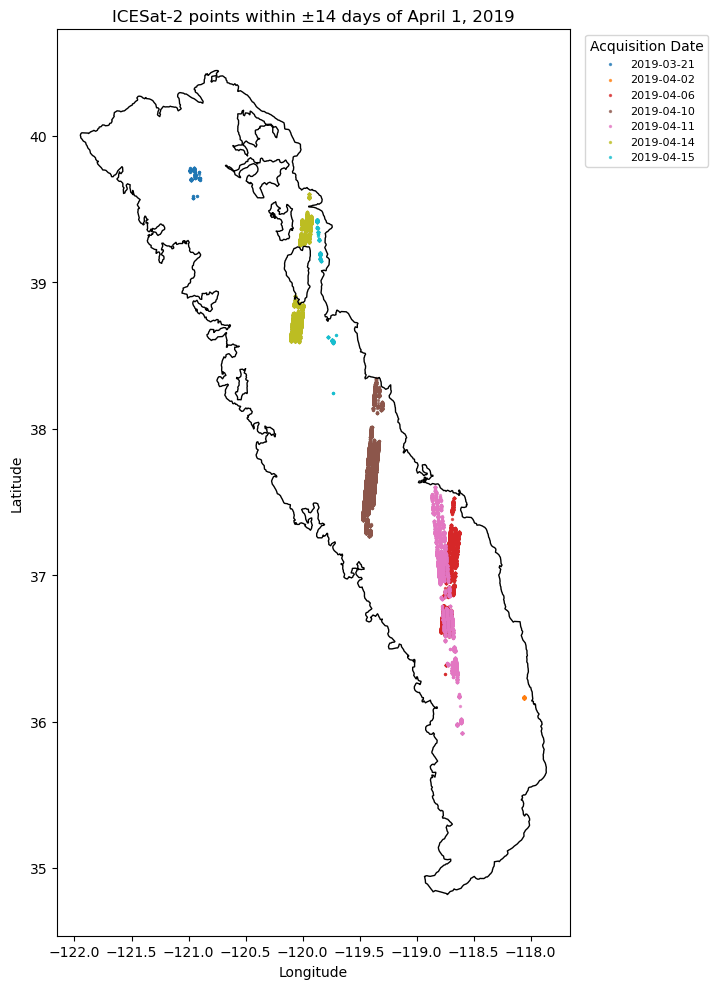

In [23]:
# Define the target date and window (two weeks centered = 7 days before and after)
target_date = pd.Timestamp('2019-04-01')
window_days = 14

# Subset to dates within two weeks centered on April 1, 2019
start_date = target_date - pd.Timedelta(days=window_days)
end_date = target_date + pd.Timedelta(days=window_days)

atl06sr_april1_2019 = atl06sr_gdf_snowy[
    (atl06sr_gdf_snowy['acqdate_dt'] >= start_date) & 
    (atl06sr_gdf_snowy['acqdate_dt'] <= end_date)
].copy()

# Print number of points and unique dates
print(f"Number of points: {len(atl06sr_april1_2019)}")
print(f"Number of unique dates: {atl06sr_april1_2019['acqdate_dt'].nunique()}")
print(f"Date range: {atl06sr_april1_2019['acqdate_dt'].min()} to {atl06sr_april1_2019['acqdate_dt'].max()}")

# Get unique dates and create a colormap
unique_dates = sorted(atl06sr_april1_2019['acqdate_dt'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_dates))

# Plot spatial location with sierras polygon, colored by date
fig, ax = plt.subplots(figsize=(10, 10))
sierras.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot each date with a different color
for i, date in enumerate(unique_dates):
    subset = atl06sr_april1_2019[atl06sr_april1_2019['acqdate_dt'] == date]
    date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
    subset.plot(ax=ax, markersize=2, alpha=0.7, color=cmap(i), label=date_str)

ax.set_title(f'ICESat-2 points within ±{window_days} days of April 1, 2019')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Acquisition Date', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

Thinking through the smoothed SA method: 

### For first date of interest, identify tracks within smoothing window:

In [24]:
atl06sr_gdf_snowy_100 = atl06sr_gdf_snowy[atl06sr_gdf_snowy['n']>100].copy()

Number of points: 36370
Number of unique dates: 7
Date range: 2019-03-04 00:00:00 to 2019-03-21 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_8804/1257996452.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))


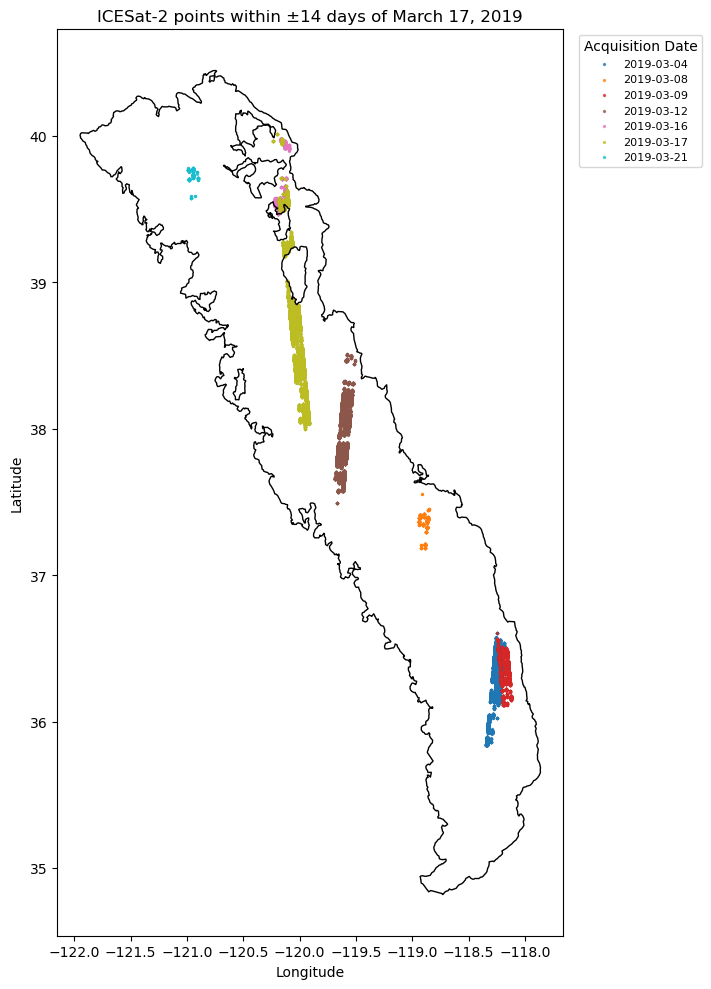

In [25]:
# Define the target date and window (two weeks centered = 7 days before and after)
target_date = pd.Timestamp('2019-03-17')
window_days = 14

# Subset to dates within two weeks centered on March 17, 2019
start_date = target_date - pd.Timedelta(days=window_days)
end_date = target_date + pd.Timedelta(days=window_days)

atl06sr_march17_2019 = atl06sr_gdf_snowy_100[
    (atl06sr_gdf_snowy_100['acqdate_dt'] >= start_date) & 
    (atl06sr_gdf_snowy_100['acqdate_dt'] <= end_date)
].copy()

# Print number of points and unique dates
print(f"Number of points: {len(atl06sr_march17_2019)}")
print(f"Number of unique dates: {atl06sr_march17_2019['acqdate_dt'].nunique()}")
print(f"Date range: {atl06sr_march17_2019['acqdate_dt'].min()} to {atl06sr_march17_2019['acqdate_dt'].max()}")

# Get unique dates and create a colormap
unique_dates = sorted(atl06sr_march17_2019['acqdate_dt'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_dates))

# Plot spatial location with sierras polygon, colored by date
fig, ax = plt.subplots(figsize=(10, 10))
sierras.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot each date with a different color
for i, date in enumerate(unique_dates):
    subset = atl06sr_march17_2019[atl06sr_march17_2019['acqdate_dt'] == date]
    date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
    subset.plot(ax=ax, markersize=2, alpha=0.7, color=cmap(i), label=date_str)

ax.set_title(f'ICESat-2 points within ±{window_days} days of March 17, 2019')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Acquisition Date', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

Steps: 
* make a separate data frame from atl06sr_gdf_snowy for just the dates selected using the +/- date window of March 17, 2019 
* sample the reanalysis years at all of these points 
* make a data frame with my atl06sr dates, with columns for the median for that date of a reanalysis water year
* calculate the rolling median for March 17 using the icesat2 data and the reanalysis data for each water year
* use the rolling median from each year to build the historical mean and stdev 
* calculate the SA of the rolling median of icesat2 versus the rolling median historical mean and stdev 
* calculate swe and compare to real march 17 data

### Sample Reanalysis at ICESat-2 points for dates within +/- 14 days of March 17 2019:

In [26]:
# Define date of interest and window
date_of_interest = pd.Timestamp('2019-03-17')
window_days = 14
current_year = 2019

# Subset atl06sr_gdf to dates within ±14 days of date_of_interest
date_min = date_of_interest - pd.Timedelta(days=window_days)
date_max = date_of_interest + pd.Timedelta(days=window_days)

atl06sr_subset = atl06sr_gdf_snowy_100[
    (atl06sr_gdf_snowy_100['acqdate_dt'] >= date_min) & 
    (atl06sr_gdf_snowy_100['acqdate_dt'] <= date_max)
].copy()

print(f"Date range: {date_min.date()} to {date_max.date()}")
print(f"Unique dates in subset: {atl06sr_subset['acqdate_dt'].dt.date.nunique()}")
print(f"Total points: {len(atl06sr_subset)}")

Date range: 2019-03-03 to 2019-03-31
Unique dates in subset: 7
Total points: 36370


In [ ]:
# swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_roi.rename({'lat': 'y', 'lon': 'x'})

In [28]:
# try this next time i need to sample

# Get all unique target dates across years
all_target_dates = []
for year in range(1985, 2022):
    for acq_date in unique_dates:
        all_target_dates.append(pd.Timestamp(f'{year}-{acq_date.month:02d}-{acq_date.day:02d}'))

# Select and compute once
sd_subset = swe_sca_ds_allyrs_roi['SD_Post'].sel(time=all_target_dates, method='nearest').compute()

KeyboardInterrupt: 

In [27]:
# Sample reanalysis snow depth data for each unique date in the subset
unique_dates = atl06sr_subset['acqdate_dt'].dt.date.unique()

for year in range(1985, 2022):
    # Initialize column with NaN
    atl06sr_subset[f'wy_{year}'] = np.nan
    
    for acq_date in unique_dates:
        # Get points for this acquisition date
        mask = atl06sr_subset['acqdate_dt'].dt.date == acq_date
        lons = atl06sr_subset.loc[mask, 'geometry'].x.values
        lats = atl06sr_subset.loc[mask, 'geometry'].y.values
        
        # Get the equivalent date in the historical year (same month/day)
        target_date = pd.Timestamp(f'{year}-{acq_date.month:02d}-{acq_date.day:02d}')
        
        # Select the snow depth data for this date
        sd_on_date = swe_sca_ds_allyrs_roi['SD_Post'].sel(time=target_date, method='nearest')
        
        # Sample at ICESat-2 points using linear interpolation
        sampled_sd = sd_on_date.interp(
            x=xr.DataArray(lons, dims='points'),
            y=xr.DataArray(lats, dims='points'),
            method='linear'
        ).values
        
        # Assign to the subset
        atl06sr_subset.loc[mask, f'wy_{year}'] = sampled_sd

print(f"Subset dataframe shape: {atl06sr_subset.shape}")
print(f"Unique dates sampled: {list(unique_dates)}")
print(f"Columns added: {[col for col in atl06sr_subset.columns if 'wy_' in col]}")


Subset dataframe shape: (36370, 87)
Unique dates sampled: [datetime.date(2019, 3, 4), datetime.date(2019, 3, 9), datetime.date(2019, 3, 8), datetime.date(2019, 3, 12), datetime.date(2019, 3, 17), datetime.date(2019, 3, 16), datetime.date(2019, 3, 21)]
Columns added: ['wy_1985', 'wy_1986', 'wy_1987', 'wy_1988', 'wy_1989', 'wy_1990', 'wy_1991', 'wy_1992', 'wy_1993', 'wy_1994', 'wy_1995', 'wy_1996', 'wy_1997', 'wy_1998', 'wy_1999', 'wy_2000', 'wy_2001', 'wy_2002', 'wy_2003', 'wy_2004', 'wy_2005', 'wy_2006', 'wy_2007', 'wy_2008', 'wy_2009', 'wy_2010', 'wy_2011', 'wy_2012', 'wy_2013', 'wy_2014', 'wy_2015', 'wy_2016', 'wy_2017', 'wy_2018', 'wy_2019', 'wy_2020', 'wy_2021']


In [29]:
# Step 1: Make a dataframe with median ICESat-2 SD and median reanalysis SD for each date
wy_cols = [col for col in atl06sr_subset.columns if col.startswith('wy_')]

# Group by date and compute medians
medians_by_date = atl06sr_subset.groupby(atl06sr_subset['acqdate_dt'].dt.date).agg(
    icesat2_median=('icesat2_3dep_dif', 'median'),
    **{col: (col, 'median') for col in wy_cols}
).reset_index()
medians_by_date.columns = ['date', 'icesat2_median'] + wy_cols
medians_by_date['date'] = pd.to_datetime(medians_by_date['date'])
medians_by_date = medians_by_date.sort_values('date')

print(f"Medians by date shape: {medians_by_date.shape}")
medians_by_date

Medians by date shape: (7, 39)


,date,icesat2_median,wy_1985,wy_1986,wy_1987,wy_1988,wy_1989,wy_1990,wy_1991,wy_1992,...,wy_2012,wy_2013,wy_2014,wy_2015,wy_2016,wy_2017,wy_2018,wy_2019,wy_2020,wy_2021
0,2019-03-04,1.558690,1.082379,1.458489,0.137666,0.600656,1.244559,0.462634,0.564388,0.985011,...,0.255086,0.353638,0.481834,0.042635,0.564133,2.094572,0.384874,1.933916,0.250297,0.165173
1,2019-03-08,2.469975,2.053002,2.996910,1.308920,1.566200,1.905773,1.204084,1.203232,1.417743,...,0.858156,1.344996,0.967307,0.579573,1.783556,3.711800,0.757542,3.069129,0.683751,1.044600
2,2019-03-09,1.824571,1.206873,1.248061,0.071772,0.445978,0.881148,0.376703,0.447078,0.936992,...,0.147285,0.331719,0.335354,0.004118,0.594845,1.607314,0.187530,1.887303,0.228847,0.057984
3,2019-03-12,2.651679,1.798235,2.776659,0.779965,0.876017,1.230143,1.086491,1.186928,0.946956,...,0.430509,0.997770,0.507879,0.019071,1.516455,2.696940,0.411807,2.687514,0.219292,1.149625
4,2019-03-16,1.056250,0.405629,1.228611,0.293726,0.101356,0.410843,0.731242,0.480061,1.112455,...,0.155822,0.179516,0.003265,0.000000,0.446023,1.342736,0.475587,1.519627,0.248073,0.569847
5,2019-03-17,2.400725,0.762332,2.299411,0.802537,0.541187,1.103145,1.166970,1.232781,1.144627,...,0.473087,0.426446,0.212242,0.001253,1.285068,2.171977,0.810149,2.480930,1.003745,1.070594
6,2019-03-21,1.591636,0.702869,0.547337,0.393294,0.323638,0.499960,0.592979,1.274726,1.070419,...,0.844624,0.080416,0.000000,0.000000,0.465467,0.963198,0.476103,1.287357,0.265075,0.359031


In [30]:
# Step 2: Calculate rolling median centered on March 17 (±14 day window)
# Use all dates in the window to compute a single "rolling median" value for March 17

# ICESat-2 rolling median for March 17
is2_rolling_median_march17 = medians_by_date['icesat2_median'].median()

# Reanalysis rolling median for March 17 for each water year
reanalysis_rolling_medians = {col: medians_by_date[col].median() for col in wy_cols}

print(f"ICESat-2 rolling median for March 17, 2019: {is2_rolling_median_march17:.4f} m")
print(f"\nReanalysis rolling medians for March 17 by water year:")
for wy, val in reanalysis_rolling_medians.items():
    print(f"  {wy}: {val:.4f} m")

ICESat-2 rolling median for March 17, 2019: 1.8246 m

Reanalysis rolling medians for March 17 by water year:
  wy_1985: 1.0824 m
  wy_1986: 1.4585 m
  wy_1987: 0.3933 m
  wy_1988: 0.5412 m
  wy_1989: 1.1031 m
  wy_1990: 0.7312 m
  wy_1991: 1.1869 m
  wy_1992: 1.0704 m
  wy_1993: 2.2873 m
  wy_1994: 0.7754 m
  wy_1995: 1.8029 m
  wy_1996: 1.3582 m
  wy_1997: 1.3346 m
  wy_1998: 1.8631 m
  wy_1999: 0.9930 m
  wy_2000: 1.3438 m
  wy_2001: 1.1376 m
  wy_2002: 1.0593 m
  wy_2003: 0.8129 m
  wy_2004: 1.5038 m
  wy_2005: 1.6674 m
  wy_2006: 1.3056 m
  wy_2007: 0.4490 m
  wy_2008: 1.6413 m
  wy_2009: 1.0149 m
  wy_2010: 1.5511 m
  wy_2011: 2.0854 m
  wy_2012: 0.4305 m
  wy_2013: 0.3536 m
  wy_2014: 0.3354 m
  wy_2015: 0.0041 m
  wy_2016: 0.5948 m
  wy_2017: 2.0946 m
  wy_2018: 0.4756 m
  wy_2019: 1.9339 m
  wy_2020: 0.2503 m
  wy_2021: 0.5698 m


In [31]:
# Step 3: Build historical mean and std from reanalysis rolling medians (excluding 2019)
reanalysis_rolling_df = pd.DataFrame.from_dict(reanalysis_rolling_medians, orient='index', columns=['rolling_median'])
reanalysis_rolling_df.index = reanalysis_rolling_df.index.str.replace('wy_', '').astype(int)
reanalysis_rolling_df.index.name = 'water_year'

# Exclude 2019 for historical statistics
historical_values = reanalysis_rolling_df.loc[reanalysis_rolling_df.index != 2019, 'rolling_median']
historical_mean = historical_values.mean()
historical_std = historical_values.std()

print(f"Historical mean (excl. 2019): {historical_mean:.4f} m")
print(f"Historical std (excl. 2019): {historical_std:.4f} m")

Historical mean (excl. 2019): 1.0740 m
Historical std (excl. 2019): 0.5802 m


In [32]:
# Step 4: Calculate the SA of ICESat-2 rolling median vs historical mean/std
march17_sa = (is2_rolling_median_march17 - historical_mean) / historical_std

print(f"ICESat-2 rolling median: {is2_rolling_median_march17:.4f} m")
print(f"Standardized Anomaly: {march17_sa:.4f}")

ICESat-2 rolling median: 1.8246 m
Standardized Anomaly: 1.2936


In [33]:
# Step 5: Convert SA back to snow depth map and compare to real March 17 data

# Select March 17 of each year for mean/std calculation (excluding 2019)
sd_allyrs_march17 = swe_sca_ds_allyrs_roi.SD_Post.sel(
    time=((swe_sca_ds_allyrs_roi['time'].dt.month == 3) & (swe_sca_ds_allyrs_roi['time'].dt.day == 17))
)

In [34]:
sd_allyrs_march17_no2019 = sd_allyrs_march17.sel(time=sd_allyrs_march17['time'].dt.year != 2019)

In [35]:
sd_march17_mean = sd_allyrs_march17_no2019.mean(dim='time', skipna=True).compute()

In [36]:
sd_march17_std = sd_allyrs_march17_no2019.std(dim='time', skipna=True).compute()

In [37]:
# Convert SA to snow depth: SD = SA * std + mean
sa_sd_estimated = (march17_sa * sd_march17_std) + sd_march17_mean

In [38]:
# Get true reanalysis for March 17, 2019
true_sd_march17 = swe_sca_ds_roi.SD_Post.sel(time='2019-03-17')

In [39]:
# Calculate difference
sa_sd_dif = (sa_sd_estimated - true_sd_march17).compute()

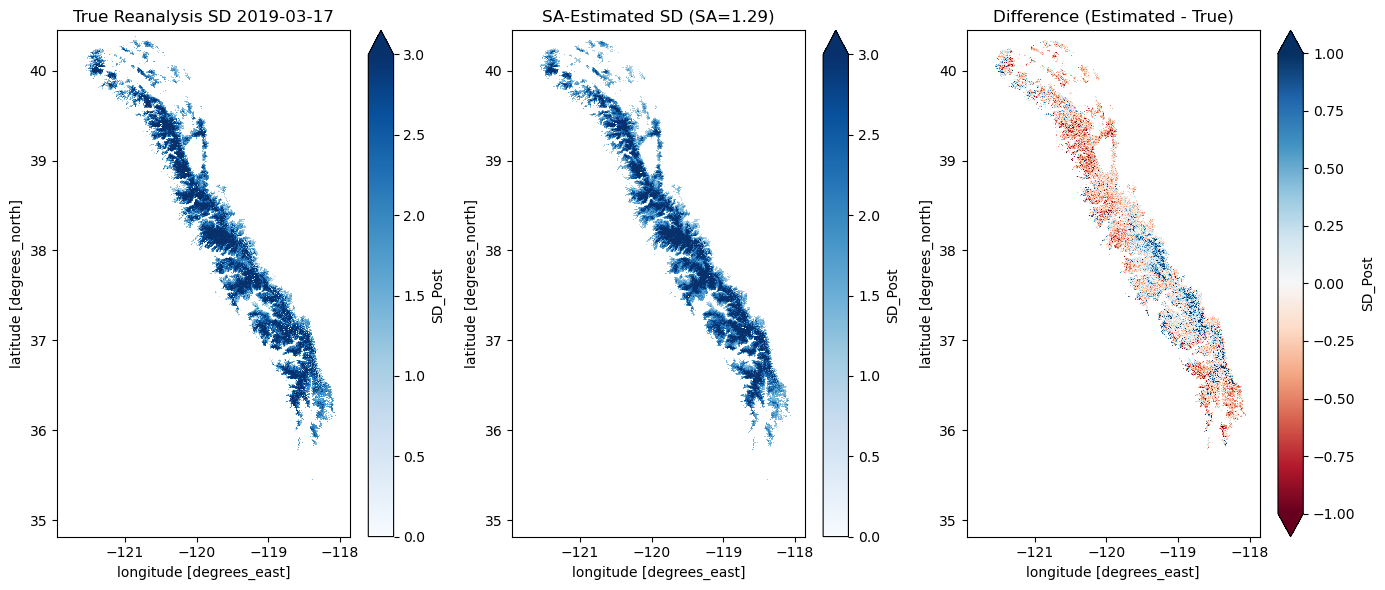

In [40]:

# Plot comparison
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

true_sd_march17.plot(ax=ax[0], cmap='Blues', vmin=0, vmax=3)
ax[0].set_title('True Reanalysis SD 2019-03-17')

sa_sd_estimated.plot(ax=ax[1], cmap='Blues', vmin=0, vmax=3)
ax[1].set_title(f'SA-Estimated SD (SA={march17_sa:.2f})')

sa_sd_dif.plot(ax=ax[2], cmap='RdBu', vmin=-1, vmax=1)
ax[2].set_title('Difference (Estimated - True)')

plt.tight_layout()

In [41]:
# Calculate metrics
true_sd = true_sd_march17.values.flatten()
pred_sd = sa_sd_estimated.values.flatten()

valid_mask = ~np.isnan(true_sd) & ~np.isnan(pred_sd)
true_sd_valid = true_sd[valid_mask]
pred_sd_valid = pred_sd[valid_mask]

bias = np.mean(pred_sd_valid - true_sd_valid)
rmse = np.sqrt(np.mean((pred_sd_valid - true_sd_valid)**2))
ss_res = np.sum((true_sd_valid - pred_sd_valid)**2)
ss_tot = np.sum((true_sd_valid - np.mean(true_sd_valid))**2)
r_squared = 1 - (ss_res / ss_tot)
pbias = 100 * np.sum(pred_sd_valid - true_sd_valid) / np.sum(true_sd_valid)

print(f"Metrics for SA-Estimated vs True Reanalysis SD (2019-03-17):")
print(f"  Bias:      {bias:.4f} m")
print(f"  RMSE:      {rmse:.4f} m")
print(f"  R²:        {r_squared:.4f}")
print(f"  PBIAS:     {pbias:.2f}%")
print(f"  N points:  {len(true_sd_valid)}")

Metrics for SA-Estimated vs True Reanalysis SD (2019-03-17):
  Bias:      -0.0476 m
  RMSE:      0.4355 m
  R²:        0.7726
  PBIAS:     -2.05%
  N points:  110501


## Run SA method for April 1 of 2019, 2020, and 2021:

In [57]:
target_dates = [
    pd.Timestamp('2019-04-01'),
    pd.Timestamp('2020-04-01'),
    pd.Timestamp('2021-04-01')
]
window_days = 14

results_is2 = []
sa_sd_maps_is2 = {}
atl06sr_subsets = {}  # Store sampled ICESat-2 subsets for each date

In [56]:
# Pre-compute April 1 snow depth for all years (for gridded mean/std)
print("Loading April 1 snow depth data...")
sd_allyrs_april1 = swe_sca_ds_allyrs_roi.SD_Post.sel(
    time=((swe_sca_ds_allyrs_roi['time'].dt.month == 4) & (swe_sca_ds_allyrs_roi['time'].dt.day == 1))
).compute()
print("Data loaded.")

Loading April 1 snow depth data...
Data loaded.


In [58]:
# Run SA method for April 1 of 2019, 2020, and 2021
# Store error statistics and snow depth maps for each year

for target_date in target_dates:
    current_year = target_date.year
    print(f"\n{'='*60}")
    print(f"Processing {target_date.strftime('%Y-%m-%d')}...")
    print(f"{'='*60}")
    
    # Step 1: Subset ICESat-2 data to ±14 days of target date
    date_min = target_date - pd.Timedelta(days=window_days)
    date_max = target_date + pd.Timedelta(days=window_days)
    
    atl06sr_subset = atl06sr_gdf_snowy_100[
        (atl06sr_gdf_snowy_100['acqdate_dt'] >= date_min) & 
        (atl06sr_gdf_snowy_100['acqdate_dt'] <= date_max)
    ].copy()
    
    print(f"Date range: {date_min.date()} to {date_max.date()}")
    print(f"Unique dates in subset: {atl06sr_subset['acqdate_dt'].dt.date.nunique()}")
    print(f"Total points: {len(atl06sr_subset)}")
    
    if len(atl06sr_subset) == 0:
        print(f"No ICESat-2 data for {current_year}, skipping...")
        continue
    
    # Step 2: Sample reanalysis at ICESat-2 points for each year
    unique_dates = atl06sr_subset['acqdate_dt'].dt.date.unique()
    
    for year in range(1985, 2022):
        atl06sr_subset[f'wy_{year}'] = np.nan
        
        for acq_date in unique_dates:
            mask = atl06sr_subset['acqdate_dt'].dt.date == acq_date
            lons = atl06sr_subset.loc[mask, 'geometry'].x.values
            lats = atl06sr_subset.loc[mask, 'geometry'].y.values
            
            hist_date = pd.Timestamp(f'{year}-{acq_date.month:02d}-{acq_date.day:02d}')
            sd_on_date = swe_sca_ds_allyrs_roi['SD_Post'].sel(time=hist_date, method='nearest')
            
            sampled_sd = sd_on_date.interp(
                x=xr.DataArray(lons, dims='points'),
                y=xr.DataArray(lats, dims='points'),
                method='linear'
            ).values
            
            atl06sr_subset.loc[mask, f'wy_{year}'] = sampled_sd
    
    # Step 3: Calculate medians by date
    wy_cols = [col for col in atl06sr_subset.columns if col.startswith('wy_')]
    medians_by_date = atl06sr_subset.groupby(atl06sr_subset['acqdate_dt'].dt.date).agg(
        icesat2_median=('icesat2_3dep_dif', 'median'),
        **{col: (col, 'median') for col in wy_cols}
    ).reset_index()
    medians_by_date.columns = ['date', 'icesat2_median'] + wy_cols
    
    # Step 4: Calculate rolling medians
    is2_rolling_median = medians_by_date['icesat2_median'].median()
    reanalysis_rolling_medians = {col: medians_by_date[col].median() for col in wy_cols}
    
    # Step 5: Historical mean/std (excluding current year)
    reanalysis_rolling_df = pd.DataFrame.from_dict(reanalysis_rolling_medians, orient='index', columns=['rolling_median'])
    reanalysis_rolling_df.index = reanalysis_rolling_df.index.str.replace('wy_', '').astype(int)
    
    historical_values = reanalysis_rolling_df.loc[reanalysis_rolling_df.index != current_year, 'rolling_median']
    historical_mean = historical_values.mean()
    historical_std = historical_values.std()
    
    # Step 6: Calculate standardized anomaly
    is2_sa = (is2_rolling_median - historical_mean) / historical_std
    print(f"ICESat-2 rolling median: {is2_rolling_median:.4f} m")
    print(f"Standardized Anomaly: {is2_sa:.4f}")
    
    # Step 7: Get gridded mean/std (excluding current year)
    sd_april1_excl = sd_allyrs_april1.sel(time=sd_allyrs_april1['time'].dt.year != current_year)
    sd_mean = sd_april1_excl.mean(dim='time', skipna=True)
    sd_std = sd_april1_excl.std(dim='time', skipna=True)
    
    # Step 8: Convert SA to snow depth map
    sa_sd_estimated = (is2_sa * sd_std) + sd_mean
    
    # Step 9: Get true reanalysis for April 1 of current year
    true_sd_april1 = sd_allyrs_april1.sel(time=sd_allyrs_april1['time'].dt.year == current_year).squeeze()
    
    # Step 10: Calculate error statistics
    true_sd = true_sd_april1.values.flatten()
    pred_sd = sa_sd_estimated.values.flatten()
    
    valid_mask = ~np.isnan(true_sd) & ~np.isnan(pred_sd)
    true_sd_valid = true_sd[valid_mask]
    pred_sd_valid = pred_sd[valid_mask]
    
    if len(true_sd_valid) > 0:
        bias = np.mean(pred_sd_valid - true_sd_valid)
        rmse = np.sqrt(np.mean((pred_sd_valid - true_sd_valid)**2))
        mae = np.mean(np.abs(pred_sd_valid - true_sd_valid))
        pbias = 100 * np.sum(pred_sd_valid - true_sd_valid) / np.sum(true_sd_valid)
        corr = np.corrcoef(true_sd_valid, pred_sd_valid)[0, 1]
        r_squared = corr ** 2
    else:
        bias = rmse = mae = r_squared = pbias = corr = np.nan
    
    print(f"\nMetrics for {current_year}:")
    print(f"  Bias: {bias:.4f} m, RMSE: {rmse:.4f} m, R²: {r_squared:.4f}, PBIAS: {pbias:.2f}%")
    
    # Store results
    results_is2.append({
        'year': current_year,
        'target_date': target_date.strftime('%Y-%m-%d'),
        'is2_rolling_median': is2_rolling_median,
        'sa': is2_sa,
        'historical_mean': historical_mean,
        'historical_std': historical_std,
        'bias': bias,
        'rmse': rmse,
        'mae': mae,
        'r_squared': r_squared,
        'pbias': pbias,
        'correlation': corr,
        'n_points': len(atl06sr_subset),
        'n_valid': len(true_sd_valid)
    })
    
    # Store snow depth map
    sa_sd_maps_is2[current_year] = sa_sd_estimated
    
    # Store atl06sr_subset (sampling takes a long time)
    atl06sr_subsets[current_year] = atl06sr_subset.copy()

results_is2_df = pd.DataFrame(results_is2)
print(f"\n{'='*60}")

print("Completed SA calculations for all target dates")
print(results_is2_df[['year', 'bias', 'rmse', 'r_squared', 'pbias']])
print(f"{'='*60}")


Processing 2019-04-01...
Date range: 2019-03-18 to 2019-04-15
Unique dates in subset: 6
Total points: 36245
ICESat-2 rolling median: 2.2700 m
Standardized Anomaly: 1.2503

Metrics for 2019:
  Bias: 0.0291 m, RMSE: 0.4529 m, R²: 0.7930, PBIAS: 1.33%

Processing 2020-04-01...
Date range: 2020-03-18 to 2020-04-15
Unique dates in subset: 5
Total points: 37221
ICESat-2 rolling median: 0.7928 m
Standardized Anomaly: -0.6282

Metrics for 2020:
  Bias: -0.0623 m, RMSE: 0.3065 m, R²: 0.7893, PBIAS: -7.16%

Processing 2021-04-01...
Date range: 2021-03-18 to 2021-04-15
Unique dates in subset: 6
Total points: 46473
ICESat-2 rolling median: 0.5075 m
Standardized Anomaly: -1.0028

Metrics for 2021:
  Bias: -0.2146 m, RMSE: 0.3725 m, R²: 0.7539, PBIAS: -29.06%

Completed SA calculations for all target dates
   year      bias      rmse  r_squared      pbias
0  2019  0.029054  0.452882   0.793010   1.334843
1  2020 -0.062270  0.306459   0.789253  -7.161710
2  2021 -0.214558  0.372509   0.753881 -29.05

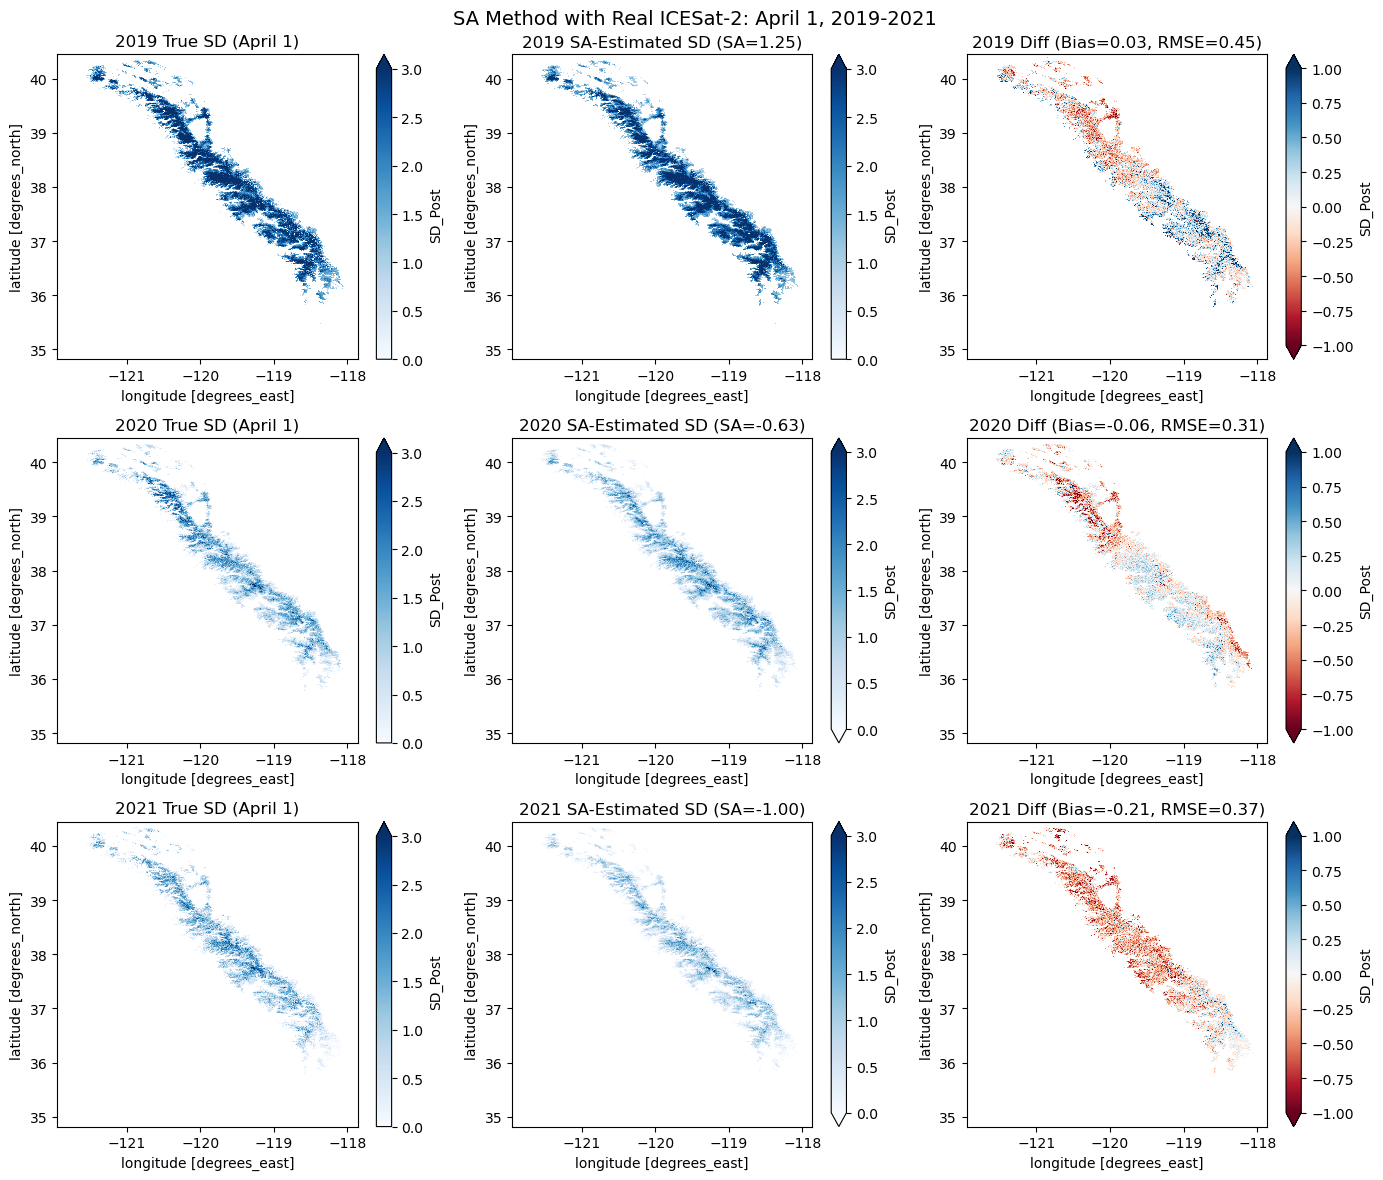

In [59]:
# Visualize results for all 3 years
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, year in enumerate(sa_sd_maps_is2.keys()):
    row = results_is2_df[results_is2_df['year'] == year].iloc[0]
    estimated = sa_sd_maps_is2[year]
    true_sd = sd_allyrs_april1.sel(time=sd_allyrs_april1['time'].dt.year == year).squeeze()
    diff = estimated - true_sd
    
    # True SD
    true_sd.plot(ax=axes[i, 0], cmap='Blues', vmin=0, vmax=3, add_colorbar=True)
    axes[i, 0].set_title(f'{year} True SD (April 1)')
    
    # Estimated SD
    estimated.plot(ax=axes[i, 1], cmap='Blues', vmin=0, vmax=3, add_colorbar=True)
    axes[i, 1].set_title(f'{year} SA-Estimated SD (SA={row["sa"]:.2f})')
    
    # Difference
    diff.plot(ax=axes[i, 2], cmap='RdBu', vmin=-1, vmax=1, add_colorbar=True)
    axes[i, 2].set_title(f'{year} Diff (Bias={row["bias"]:.2f}, RMSE={row["rmse"]:.2f})')

plt.suptitle('SA Method with Real ICESat-2: April 1, 2019-2021', fontsize=14)
plt.tight_layout()
plt.show()

In [60]:
# Save results
results_is2_df.to_csv('../data/results/sa_real_is2_error_stats_april1.csv', index=False)

# Save snow depth maps as xarray dataset
years_with_maps = list(sa_sd_maps_is2.keys())
sa_sd_ds_is2 = xr.concat(
    [sa_sd_maps_is2[yr].expand_dims(year=[yr]) for yr in years_with_maps],
    dim='year'
)
sa_sd_ds_is2.name = 'sa_estimated_sd'
sa_sd_ds_is2.to_netcdf('../data/results/sa_real_is2_sd_maps_april1.nc')

# Save atl06sr_subsets (sampling is time-consuming)
import pickle
with open('../data/results/atl06sr_subsets_april1.pkl', 'wb') as f:
    pickle.dump(atl06sr_subsets, f)

print(f"Saved error statistics to '../data/results/sa_real_is2_error_stats_april1.csv'")
print(f"Saved snow depth maps to '../data/results/sa_real_is2_sd_maps_april1.nc'")
print(f"Saved ICESat-2 subsets to '../data/results/atl06sr_subsets_april1.pkl'")
print(f"\nResults summary:")
print(results_is2_df)

Saved error statistics to '../data/results/sa_real_is2_error_stats_april1.csv'
Saved snow depth maps to '../data/results/sa_real_is2_sd_maps_april1.nc'
Saved ICESat-2 subsets to '../data/results/atl06sr_subsets_april1.pkl'

Results summary:
   year target_date  is2_rolling_median        sa  historical_mean  \
0  2019  2019-04-01            2.269993  1.250308         1.278530   
1  2020  2020-04-01            0.792774 -0.628226         1.291448   
2  2021  2021-04-01            0.507519 -1.002753         1.256048   

   historical_std      bias      rmse       mae  r_squared      pbias  \
0        0.792975  0.029054  0.452882  0.324544   0.793010   1.334843   
1        0.793781 -0.062270  0.306459  0.225258   0.789253  -7.161710   
2        0.746474 -0.214558  0.372509  0.287703   0.753881 -29.057509   

   correlation  n_points  n_valid  
0     0.890511     36245   110501  
1     0.888399     37221   110501  
2     0.868263     46473   110501  


### For second date of interest, identify tracks within smoothing window:

Number of points: 45002
Number of unique dates: 8
Date range: 2019-04-02 00:00:00 to 2019-04-19 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_8804/1577366285.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))


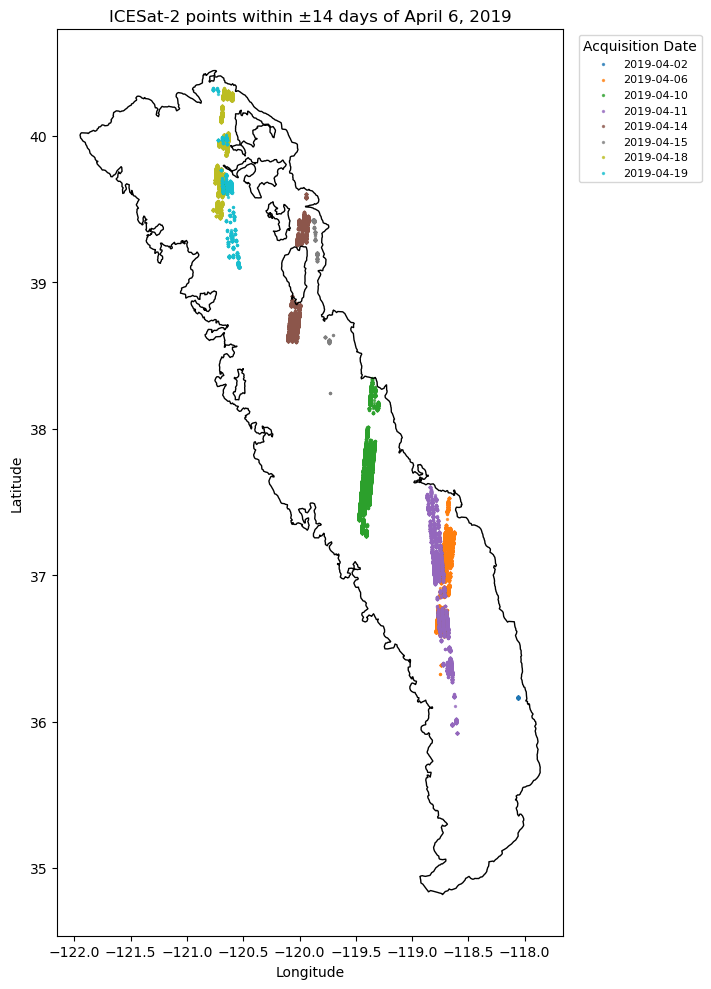

In [43]:
# Define the target date and window (two weeks centered = 7 days before and after)
target_date = pd.Timestamp('2019-04-06')
window_days = 14

# Subset to dates within two weeks centered on April 6, 2019
start_date = target_date - pd.Timedelta(days=window_days)
end_date = target_date + pd.Timedelta(days=window_days)

atl06sr_april6_2019 = atl06sr_gdf_snowy[
    (atl06sr_gdf_snowy['acqdate_dt'] >= start_date) & 
    (atl06sr_gdf_snowy['acqdate_dt'] <= end_date)
].copy()

# Print number of points and unique dates
print(f"Number of points: {len(atl06sr_april6_2019)}")
print(f"Number of unique dates: {atl06sr_april6_2019['acqdate_dt'].nunique()}")
print(f"Date range: {atl06sr_april6_2019['acqdate_dt'].min()} to {atl06sr_april6_2019['acqdate_dt'].max()}")

# Get unique dates and create a colormap
unique_dates = sorted(atl06sr_april6_2019['acqdate_dt'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_dates))

# Plot spatial location with sierras polygon, colored by date
fig, ax = plt.subplots(figsize=(10, 10))
sierras.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot each date with a different color
for i, date in enumerate(unique_dates):
    subset = atl06sr_april6_2019[atl06sr_april6_2019['acqdate_dt'] == date]
    date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
    subset.plot(ax=ax, markersize=2, alpha=0.7, color=cmap(i), label=date_str)

ax.set_title(f'ICESat-2 points within ±{window_days} days of April 6, 2019')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Acquisition Date', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

In [44]:
# Define date of interest and window
date_of_interest = pd.Timestamp('2019-04-06')
window_days = 14
current_year = 2019

# Subset atl06sr_gdf to dates within ±14 days of date_of_interest
date_min = date_of_interest - pd.Timedelta(days=window_days)
date_max = date_of_interest + pd.Timedelta(days=window_days)

atl06sr_subset_apr6 = atl06sr_gdf_snowy_100[
    (atl06sr_gdf_snowy_100['acqdate_dt'] >= date_min) & 
    (atl06sr_gdf_snowy_100['acqdate_dt'] <= date_max)
].copy()

print(f"Date range: {date_min.date()} to {date_max.date()}")
print(f"Unique dates in subset: {atl06sr_subset_apr6['acqdate_dt'].dt.date.nunique()}")
print(f"Total points: {len(atl06sr_subset_apr6)}")

Date range: 2019-03-23 to 2019-04-20
Unique dates in subset: 7
Total points: 44928


In [ ]:
# # try this next time i need to sample

# # Get all unique target dates across years
# all_target_dates = []
# for year in range(1985, 2022):
#     for acq_date in unique_dates:
#         all_target_dates.append(pd.Timestamp(f'{year}-{acq_date.month:02d}-{acq_date.day:02d}'))

# # Select and compute once
# sd_subset = swe_sca_ds_allyrs_roi['SD_Post'].sel(time=all_target_dates, method='nearest').compute()

Date range: 2019-03-03 to 2019-03-31
Unique dates in subset: 7
Total points: 36370


In [45]:
# Sample reanalysis snow depth data for each unique date in the April 6 subset
unique_dates_apr6 = atl06sr_subset_apr6['acqdate_dt'].dt.date.unique()

for year in range(1985, 2022):
    # Initialize column with NaN
    atl06sr_subset_apr6[f'wy_{year}'] = np.nan
    
    for acq_date in unique_dates_apr6:
        # Get points for this acquisition date
        mask = atl06sr_subset_apr6['acqdate_dt'].dt.date == acq_date
        lons = atl06sr_subset_apr6.loc[mask, 'geometry'].x.values
        lats = atl06sr_subset_apr6.loc[mask, 'geometry'].y.values
        
        # Get the equivalent date in the historical year (same month/day)
        target_date = pd.Timestamp(f'{year}-{acq_date.month:02d}-{acq_date.day:02d}')
        
        # Select the snow depth data for this date
        sd_on_date = swe_sca_ds_allyrs_roi['SD_Post'].sel(time=target_date, method='nearest')
        
        # Sample at ICESat-2 points using linear interpolation
        sampled_sd = sd_on_date.interp(
            x=xr.DataArray(lons, dims='points'),
            y=xr.DataArray(lats, dims='points'),
            method='linear'
        ).values
        
        # Assign to the subset
        atl06sr_subset_apr6.loc[mask, f'wy_{year}'] = sampled_sd

print(f"Subset dataframe shape: {atl06sr_subset_apr6.shape}")
print(f"Unique dates sampled: {list(unique_dates_apr6)}")

Subset dataframe shape: (44928, 87)
Unique dates sampled: [datetime.date(2019, 4, 11), datetime.date(2019, 4, 6), datetime.date(2019, 4, 10), datetime.date(2019, 4, 15), datetime.date(2019, 4, 14), datetime.date(2019, 4, 19), datetime.date(2019, 4, 18)]


In [46]:
# Step 1: Make a dataframe with median ICESat-2 SD and median reanalysis SD for each date
wy_cols_apr6 = [col for col in atl06sr_subset_apr6.columns if col.startswith('wy_')]

# Group by date and compute medians
medians_by_date_apr6 = atl06sr_subset_apr6.groupby(atl06sr_subset_apr6['acqdate_dt'].dt.date).agg(
    icesat2_median=('icesat2_3dep_dif', 'median'),
    **{col: (col, 'median') for col in wy_cols_apr6}
).reset_index()
medians_by_date_apr6.columns = ['date', 'icesat2_median'] + wy_cols_apr6
medians_by_date_apr6['date'] = pd.to_datetime(medians_by_date_apr6['date'])
medians_by_date_apr6 = medians_by_date_apr6.sort_values('date')

print(f"Medians by date shape: {medians_by_date_apr6.shape}")
medians_by_date_apr6

Medians by date shape: (7, 39)


,date,icesat2_median,wy_1985,wy_1986,wy_1987,wy_1988,wy_1989,wy_1990,wy_1991,wy_1992,...,wy_2012,wy_2013,wy_2014,wy_2015,wy_2016,wy_2017,wy_2018,wy_2019,wy_2020,wy_2021
0,2019-04-06,2.566504,1.623117,2.777530,1.091382,0.398602,1.089855,0.476728,1.733529,1.280350,...,0.806417,0.528757,0.523391,0.017723,0.955027,2.473299,0.975830,2.618834,1.171171,0.487603
1,2019-04-10,2.236279,1.334060,2.487868,0.925539,0.279187,0.909838,0.315514,1.464195,1.017148,...,0.577914,0.683522,0.448344,0.015156,1.096119,2.805858,0.548086,2.282971,1.055481,0.596258
2,2019-04-11,2.759202,1.403774,2.805671,0.915293,0.314070,0.891054,0.384503,1.640693,1.049383,...,0.759285,0.566697,0.318711,0.014640,1.170982,2.682626,0.714413,2.480020,1.180383,0.415615
3,2019-04-14,2.303706,0.811533,2.069972,0.335449,0.275977,0.744100,0.486206,1.327672,0.527483,...,0.873476,0.625996,0.389971,0.028863,1.310885,2.792203,0.701946,2.461492,1.332878,0.746975
4,2019-04-15,0.951551,0.024604,0.644845,0.052867,0.021081,0.149921,0.017586,0.354814,0.209948,...,0.085843,0.030057,0.003218,0.000000,0.150705,0.962304,0.056612,0.902652,0.428792,0.263501
5,2019-04-18,1.447068,0.592737,1.048043,0.128492,0.094899,0.305489,0.143672,0.993247,0.237495,...,0.614495,0.113495,0.002174,0.000000,0.366405,1.534341,0.230453,1.502128,0.530128,0.299469
6,2019-04-19,1.475121,0.628178,0.882855,0.200618,0.144437,0.449611,0.149907,0.936828,0.233444,...,0.698194,0.080111,0.007918,0.000000,0.454291,1.797674,0.350857,1.698278,0.621000,0.295316


In [47]:
# Step 2: Calculate rolling median for April 6 (±14 day window)
# ICESat-2 rolling median for April 6
is2_rolling_median_apr6 = medians_by_date_apr6['icesat2_median'].median()

# Reanalysis rolling median for April 6 for each water year
reanalysis_rolling_medians_apr6 = {col: medians_by_date_apr6[col].median() for col in wy_cols_apr6}

print(f"ICESat-2 rolling median for April 6, 2019: {is2_rolling_median_apr6:.4f} m")
print(f"\nReanalysis rolling medians for April 6 by water year:")
for wy, val in list(reanalysis_rolling_medians_apr6.items())[:5]:
    print(f"  {wy}: {val:.4f} m")
print("  ...")

ICESat-2 rolling median for April 6, 2019: 2.2363 m

Reanalysis rolling medians for April 6 by water year:
  wy_1985: 0.8115 m
  wy_1986: 2.0700 m
  wy_1987: 0.3354 m
  wy_1988: 0.2760 m
  wy_1989: 0.7441 m
  ...


In [48]:
# Step 3: Build historical mean and std from reanalysis rolling medians (excluding 2019)
reanalysis_rolling_df_apr6 = pd.DataFrame.from_dict(reanalysis_rolling_medians_apr6, orient='index', columns=['rolling_median'])
reanalysis_rolling_df_apr6.index = reanalysis_rolling_df_apr6.index.str.replace('wy_', '').astype(int)
reanalysis_rolling_df_apr6.index.name = 'water_year'

# Exclude 2019 for historical statistics
historical_values_apr6 = reanalysis_rolling_df_apr6.loc[reanalysis_rolling_df_apr6.index != 2019, 'rolling_median']
historical_mean_apr6 = historical_values_apr6.mean()
historical_std_apr6 = historical_values_apr6.std()

print(f"Historical mean (excl. 2019): {historical_mean_apr6:.4f} m")
print(f"Historical std (excl. 2019): {historical_std_apr6:.4f} m")

Historical mean (excl. 2019): 1.1702 m
Historical std (excl. 2019): 0.7803 m


In [49]:
# Step 4: Calculate the SA of ICESat-2 rolling median vs historical mean/std
apr6_sa = (is2_rolling_median_apr6 - historical_mean_apr6) / historical_std_apr6

print(f"ICESat-2 rolling median: {is2_rolling_median_apr6:.4f} m")
print(f"Standardized Anomaly: {apr6_sa:.4f}")

ICESat-2 rolling median: 2.2363 m
Standardized Anomaly: 1.3663


In [50]:
# Step 5: Convert SA back to snow depth map and compare to real April 6 data

# Select April 6 of each year for mean/std calculation (excluding 2019)
sd_allyrs_apr6 = swe_sca_ds_allyrs_roi.SD_Post.sel(
    time=((swe_sca_ds_allyrs_roi['time'].dt.month == 4) & (swe_sca_ds_allyrs_roi['time'].dt.day == 6))
    )

In [51]:
sd_allyrs_apr6_no2019 = sd_allyrs_apr6.sel(time=sd_allyrs_apr6['time'].dt.year != 2019)

In [52]:
sd_apr6_mean = sd_allyrs_apr6_no2019.mean(dim='time', skipna=True).compute()

In [53]:
sd_apr6_std = sd_allyrs_apr6_no2019.std(dim='time', skipna=True).compute()

In [54]:
# Convert SA to snow depth: SD = SA * std + mean
sa_sd_estimated_apr6 = (apr6_sa * sd_apr6_std) + sd_apr6_mean

In [55]:
# Get true reanalysis for April 6, 2019
true_sd_apr6 = swe_sca_ds_roi.SD_Post.sel(time='2019-04-06')

In [56]:
# Calculate difference
sa_sd_dif_apr6 = (sa_sd_estimated_apr6 - true_sd_apr6).compute()

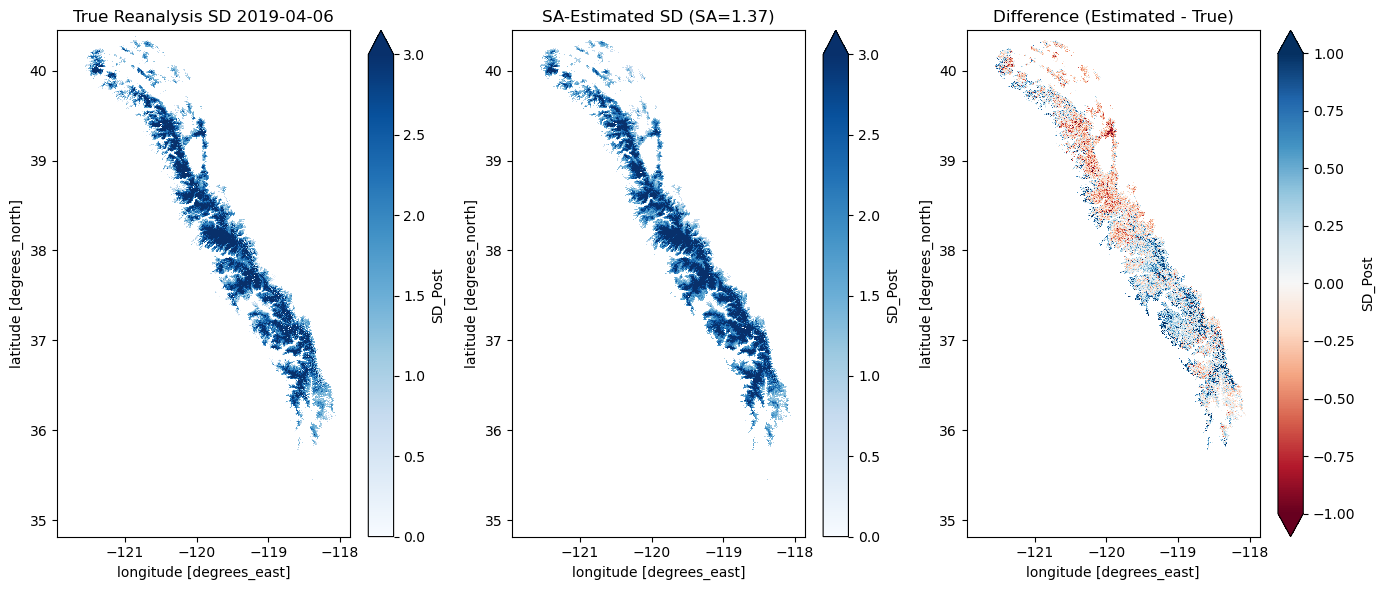

In [57]:
# Plot comparison for April 6, 2019
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

true_sd_apr6.plot(ax=ax[0], cmap='Blues', vmin=0, vmax=3)
ax[0].set_title('True Reanalysis SD 2019-04-06')

sa_sd_estimated_apr6.plot(ax=ax[1], cmap='Blues', vmin=0, vmax=3)
ax[1].set_title(f'SA-Estimated SD (SA={apr6_sa:.2f})')

sa_sd_dif_apr6.plot(ax=ax[2], cmap='RdBu', vmin=-1, vmax=1)
ax[2].set_title('Difference (Estimated - True)')

plt.tight_layout()

In [58]:
# Calculate metrics for April 6, 2019
true_sd_apr6_vals = true_sd_apr6.values.flatten()
pred_sd_apr6_vals = sa_sd_estimated_apr6.values.flatten()

valid_mask_apr6 = ~np.isnan(true_sd_apr6_vals) & ~np.isnan(pred_sd_apr6_vals)
true_sd_valid_apr6 = true_sd_apr6_vals[valid_mask_apr6]
pred_sd_valid_apr6 = pred_sd_apr6_vals[valid_mask_apr6]

bias_apr6 = np.mean(pred_sd_valid_apr6 - true_sd_valid_apr6)
rmse_apr6 = np.sqrt(np.mean((pred_sd_valid_apr6 - true_sd_valid_apr6)**2))
ss_res_apr6 = np.sum((true_sd_valid_apr6 - pred_sd_valid_apr6)**2)
ss_tot_apr6 = np.sum((true_sd_valid_apr6 - np.mean(true_sd_valid_apr6))**2)
r_squared_apr6 = 1 - (ss_res_apr6 / ss_tot_apr6)
pbias_apr6 = 100 * np.sum(pred_sd_valid_apr6 - true_sd_valid_apr6) / np.sum(true_sd_valid_apr6)

print(f"Metrics for SA-Estimated vs True Reanalysis SD (2019-04-06):")
print(f"  Bias:      {bias_apr6:.4f} m")
print(f"  RMSE:      {rmse_apr6:.4f} m")
print(f"  R²:        {r_squared_apr6:.4f}")
print(f"  PBIAS:     {pbias_apr6:.2f}%")
print(f"  N points:  {len(true_sd_valid_apr6)}")

Metrics for SA-Estimated vs True Reanalysis SD (2019-04-06):
  Bias:      0.0868 m
  RMSE:      0.4581 m
  R²:        0.8052
  PBIAS:     4.04%
  N points:  110501


Number of points: 36245
Number of unique dates: 6
Date range: 2019-03-21 00:00:00 to 2019-04-15 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_8804/3825147142.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))


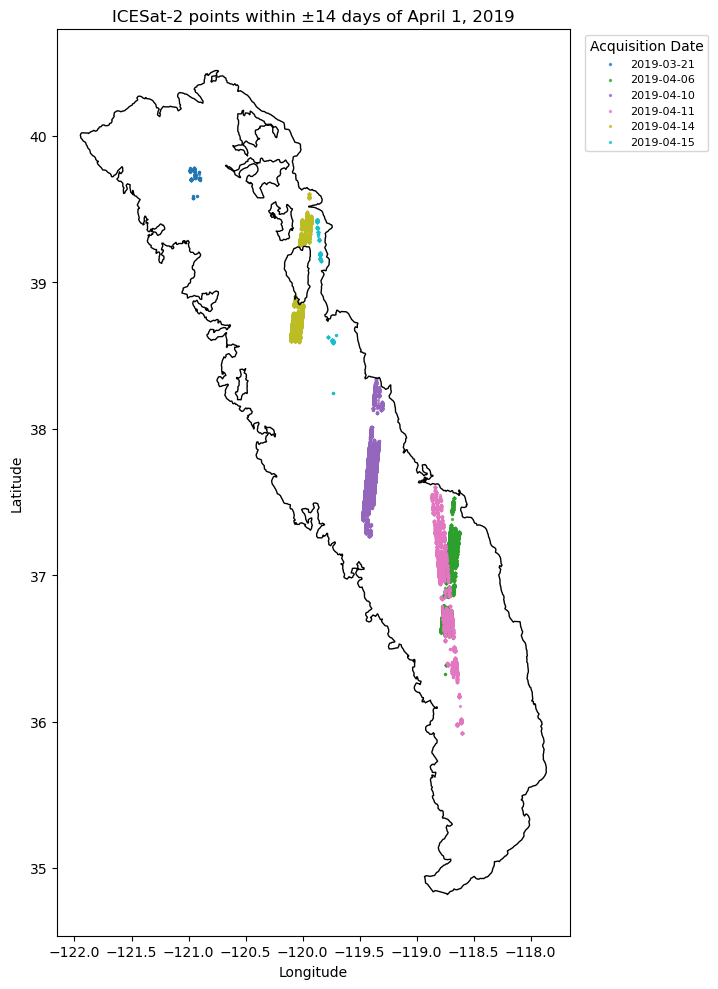

In [59]:
# Define the target date and window (two weeks centered = 7 days before and after)
target_date = pd.Timestamp('2019-04-01')
window_days = 14

# Subset to dates within two weeks centered on March 17, 2019
start_date = target_date - pd.Timedelta(days=window_days)
end_date = target_date + pd.Timedelta(days=window_days)

atl06sr_march17_2019 = atl06sr_gdf_snowy_100[
    (atl06sr_gdf_snowy_100['acqdate_dt'] >= start_date) & 
    (atl06sr_gdf_snowy_100['acqdate_dt'] <= end_date)
].copy()

# Print number of points and unique dates
print(f"Number of points: {len(atl06sr_march17_2019)}")
print(f"Number of unique dates: {atl06sr_march17_2019['acqdate_dt'].nunique()}")
print(f"Date range: {atl06sr_march17_2019['acqdate_dt'].min()} to {atl06sr_march17_2019['acqdate_dt'].max()}")

# Get unique dates and create a colormap
unique_dates = sorted(atl06sr_march17_2019['acqdate_dt'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_dates))

# Plot spatial location with sierras polygon, colored by date
fig, ax = plt.subplots(figsize=(10, 10))
sierras.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot each date with a different color
for i, date in enumerate(unique_dates):
    subset = atl06sr_march17_2019[atl06sr_march17_2019['acqdate_dt'] == date]
    date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
    subset.plot(ax=ax, markersize=2, alpha=0.7, color=cmap(i), label=date_str)

ax.set_title(f'ICESat-2 points within ±{window_days} days of April 1, 2019')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Acquisition Date', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

Number of points: 37221
Number of unique dates: 5
Date range: 2020-04-03 00:00:00 to 2020-04-15 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_8804/3064793364.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))


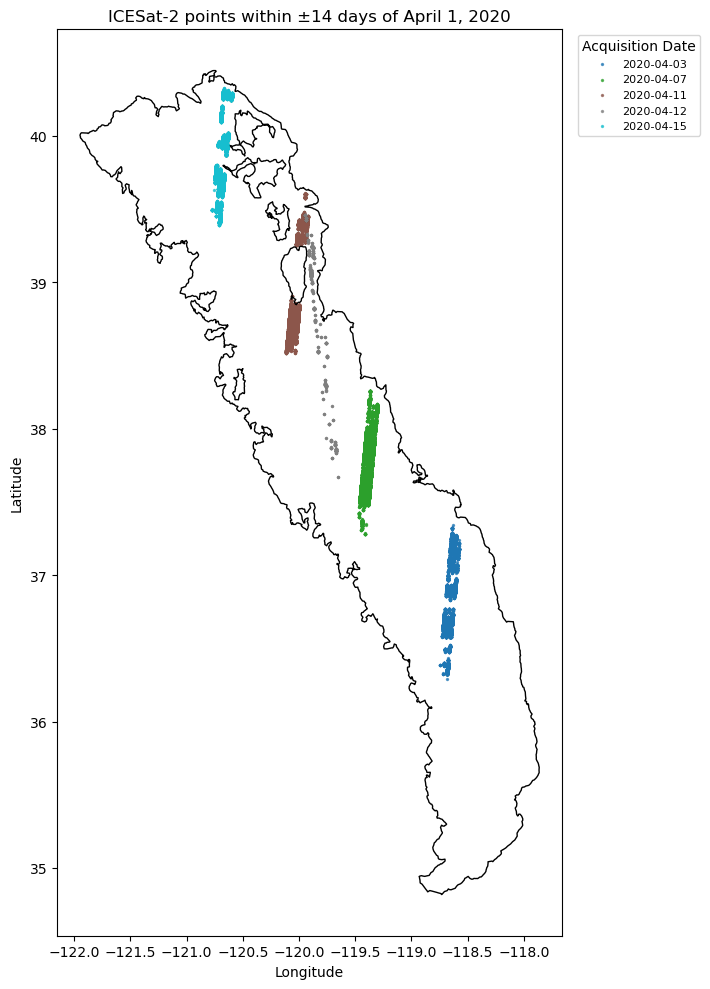

In [60]:
# Define the target date and window (two weeks centered = 7 days before and after)
target_date = pd.Timestamp('2020-04-01')
window_days = 14

# Subset to dates within two weeks centered on March 17, 2019
start_date = target_date - pd.Timedelta(days=window_days)
end_date = target_date + pd.Timedelta(days=window_days)

atl06sr_march17_2019 = atl06sr_gdf_snowy_100[
    (atl06sr_gdf_snowy_100['acqdate_dt'] >= start_date) & 
    (atl06sr_gdf_snowy_100['acqdate_dt'] <= end_date)
].copy()

# Print number of points and unique dates
print(f"Number of points: {len(atl06sr_march17_2019)}")
print(f"Number of unique dates: {atl06sr_march17_2019['acqdate_dt'].nunique()}")
print(f"Date range: {atl06sr_march17_2019['acqdate_dt'].min()} to {atl06sr_march17_2019['acqdate_dt'].max()}")

# Get unique dates and create a colormap
unique_dates = sorted(atl06sr_march17_2019['acqdate_dt'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_dates))

# Plot spatial location with sierras polygon, colored by date
fig, ax = plt.subplots(figsize=(10, 10))
sierras.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot each date with a different color
for i, date in enumerate(unique_dates):
    subset = atl06sr_march17_2019[atl06sr_march17_2019['acqdate_dt'] == date]
    date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
    subset.plot(ax=ax, markersize=2, alpha=0.7, color=cmap(i), label=date_str)

ax.set_title(f'ICESat-2 points within ±{window_days} days of April 1, 2020')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Acquisition Date', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

Number of points: 46473
Number of unique dates: 6
Date range: 2021-04-01 00:00:00 to 2021-04-15 00:00:00


/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_8804/2704918022.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_dates))


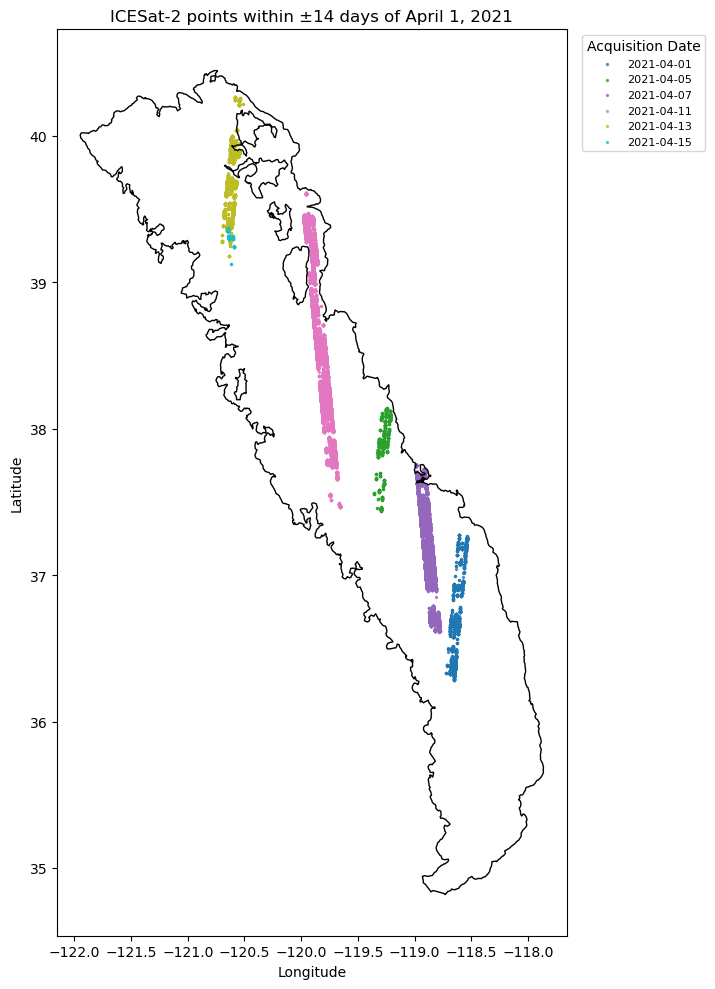

In [61]:
# Define the target date and window (two weeks centered = 7 days before and after)
target_date = pd.Timestamp('2021-04-01')
window_days = 14

# Subset to dates within two weeks centered on March 17, 2019
start_date = target_date - pd.Timedelta(days=window_days)
end_date = target_date + pd.Timedelta(days=window_days)

atl06sr_march17_2019 = atl06sr_gdf_snowy_100[
    (atl06sr_gdf_snowy_100['acqdate_dt'] >= start_date) & 
    (atl06sr_gdf_snowy_100['acqdate_dt'] <= end_date)
].copy()

# Print number of points and unique dates
print(f"Number of points: {len(atl06sr_march17_2019)}")
print(f"Number of unique dates: {atl06sr_march17_2019['acqdate_dt'].nunique()}")
print(f"Date range: {atl06sr_march17_2019['acqdate_dt'].min()} to {atl06sr_march17_2019['acqdate_dt'].max()}")

# Get unique dates and create a colormap
unique_dates = sorted(atl06sr_march17_2019['acqdate_dt'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_dates))

# Plot spatial location with sierras polygon, colored by date
fig, ax = plt.subplots(figsize=(10, 10))
sierras.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot each date with a different color
for i, date in enumerate(unique_dates):
    subset = atl06sr_march17_2019[atl06sr_march17_2019['acqdate_dt'] == date]
    date_str = pd.Timestamp(date).strftime('%Y-%m-%d')
    subset.plot(ax=ax, markersize=2, alpha=0.7, color=cmap(i), label=date_str)

ax.set_title(f'ICESat-2 points within ±{window_days} days of April 1, 2021')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Acquisition Date', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()